In [1]:
# Cell 1: 基础环境 & 随机种子

import os
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import HeteroData

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, recall_score

import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

def set_seed(seed=51):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(51)


Device: cuda


In [2]:
# Cell 2: 加载 hetero_data.pt，并准备元信息

HET_PATH = os.path.join(".", "data", "hetero_data.pt")
data_obj = torch.load(HET_PATH)

if isinstance(data_obj, HeteroData):
    hetero_data = data_obj
elif isinstance(data_obj, dict) and 'hetero_data' in data_obj:
    hetero_data = data_obj['hetero_data']
else:
    raise ValueError("无法识别 hetero_data 格式，请确认 hetero_data.pt 里存的是 HeteroData 或 {'hetero_data': HeteroData}.")

print(hetero_data)

# 元信息
node_types, edge_types = hetero_data.metadata()
print("Node types:", node_types)
print("Edge types:", edge_types)

# 每种节点类型的输入维度
in_dims = {ntype: hetero_data[ntype].x.size(1) for ntype in node_types}
print("Input dims per node type:", in_dims)

# 拷贝一份特征到 CPU（训练时再整体搬到 device）
x_dict = {ntype: hetero_data[ntype].x.clone() for ntype in node_types}


HeteroData(
  protein={
    x=[18326, 150],
    y=[18326],
  },
  lncrna={ x=[1811, 150] },
  mirna={ x=[1589, 150] },
  (lncrna, lncrnaTOlncrna, lncrna)={ edge_index=[2, 296] },
  (lncrna, lncrnaTOmirna, mirna)={ edge_index=[2, 7277] },
  (lncrna, lncrnaTOprotein, protein)={ edge_index=[2, 10376] },
  (mirna, mirnaTOlncrna, lncrna)={ edge_index=[2, 7277] },
  (mirna, mirnaTOmirna, mirna)={ edge_index=[2, 158] },
  (mirna, mirnaTOprotein, protein)={ edge_index=[2, 510229] },
  (protein, proteinTOlncrna, lncrna)={ edge_index=[2, 10376] },
  (protein, proteinTOmirna, mirna)={ edge_index=[2, 510229] },
  (protein, proteinTOprotein, protein)={ edge_index=[2, 939078] }
)
Node types: ['protein', 'lncrna', 'mirna']
Edge types: [('lncrna', 'lncrnaTOlncrna', 'lncrna'), ('lncrna', 'lncrnaTOmirna', 'mirna'), ('lncrna', 'lncrnaTOprotein', 'protein'), ('mirna', 'mirnaTOlncrna', 'lncrna'), ('mirna', 'mirnaTOmirna', 'mirna'), ('mirna', 'mirnaTOprotein', 'protein'), ('protein', 'proteinTOlncrna', 'lnc

In [3]:
# 假设 metadata = (node_types, edge_types)
_, edge_types = hetero_data.metadata()
missing = [e for e in edge_types if e not in hetero_data.edge_index_dict]
extra   = [e for e in hetero_data.edge_index_dict.keys() if e not in edge_types]
print("missing edge_types:", missing)
print("extra edge_types:", extra)
assert len(missing) == 0, "Some edge types in metadata are missing in edge_index_dict!"


missing edge_types: []
extra edge_types: []


In [4]:
# Cell 2.1: 构造不同消融实验的 metadata

full_node_types, full_edge_types = hetero_data.metadata()
print("Full node types :", full_node_types)
print("Full edge types :", full_edge_types)

def make_metadata(mode: str):
    """
    mode:
        'full'         : 原始模型，保留所有关系
        'no_lnc'       : 去除所有与 lncrna 相关的边
        'no_mir'       : 去除所有与 mirna 相关的边
        'no_lnc_mir'   : 去除 lncrna & mirna，只保留 PPI (protein-protein)
    """
    if mode == 'full':
        edge_types = full_edge_types

    elif mode == 'no_lnc':
        edge_types = [
            et for et in full_edge_types
            if (et[0] != 'lncrna' and et[2] != 'lncrna')
        ]

    elif mode == 'no_mir':
        edge_types = [
            et for et in full_edge_types
            if (et[0] != 'mirna' and et[2] != 'mirna')
        ]

    elif mode == 'no_lnc_mir':
        edge_types = [
            et for et in full_edge_types
            if (et[0] == 'protein' and et[2] == 'protein')
        ]
    else:
        raise ValueError(f"Unknown ablation mode: {mode}")

    print(f"[{mode}] edge_types used:")
    for et in edge_types:
        print("   ", et)

    return (full_node_types, edge_types)


Full node types : ['protein', 'lncrna', 'mirna']
Full edge types : [('lncrna', 'lncrnaTOlncrna', 'lncrna'), ('lncrna', 'lncrnaTOmirna', 'mirna'), ('lncrna', 'lncrnaTOprotein', 'protein'), ('mirna', 'mirnaTOlncrna', 'lncrna'), ('mirna', 'mirnaTOmirna', 'mirna'), ('mirna', 'mirnaTOprotein', 'protein'), ('protein', 'proteinTOlncrna', 'lncrna'), ('protein', 'proteinTOmirna', 'mirna'), ('protein', 'proteinTOprotein', 'protein')]


In [ ]:
# Cell 2.2: 随机遮掩部分边（按比例删除），用于鲁棒性消融

def random_mask_edges(hetero_data, drop_ratio: float, seed: int = 51):
    """
    在 hetero_data 上随机删除 drop_ratio 比例的边（每种关系分别按比例删），
    不改动节点和标签，返回一个新的 HeteroData。
    drop_ratio = 0.1 表示删除 10% 的边。
    """
    assert 0.0 <= drop_ratio < 1.0
    if drop_ratio == 0.0:
        return hetero_data  # 不删边，直接返回原图

    data = hetero_data.clone()
    g = torch.Generator()
    g.manual_seed(seed)

    for edge_type in data.edge_types:
        # edge_type 形如 ('lncrna','lnc-protein','protein')
        edge_index = data[edge_type].edge_index
        num_edges = edge_index.size(1)

        keep_num = int(num_edges * (1.0 - drop_ratio))
        if keep_num <= 0:
            print(f"[WARN] edge_type {edge_type} all edges would be dropped, skip.")
            continue

        perm = torch.randperm(num_edges, generator=g)
        keep_idx = perm[:keep_num]

        data[edge_type].edge_index = edge_index[:, keep_idx]

        # 如果有 edge_weight / edge_attr 一起裁剪
        if 'edge_weight' in data[edge_type]:
            data[edge_type].edge_weight = data[edge_type].edge_weight[keep_idx]
        if 'edge_attr' in data[edge_type]:
            data[edge_type].edge_attr = data[edge_type].edge_attr[keep_idx]

        print(f"[drop {drop_ratio:.2f}] {edge_type}: {num_edges} -> {keep_num} edges")

    return data


In [6]:
# （加入了注意力缓存）Cell 3: 定义 MRAGDM 模型（多路 + 注意力 + 扩散）与 ProteinClassifier
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing


class CouplingAttention(nn.Module):
    """
    多路耦合注意力：在同一节点类型上融合不同关系得到的表示。
    输入: x: [N, R, D]
    输出: out: [N, D]
    额外：可选缓存 last_weight: [N, R]
    """
    def __init__(self, in_dim: int, dim_a: int):
        super().__init__()
        self.proj = nn.Linear(in_dim, dim_a)
        self.attn = nn.Linear(dim_a, 1)
        self.norm = nn.LayerNorm(in_dim)
        self.residual = nn.Sequential(
            nn.Linear(in_dim, in_dim * 2),
            nn.GELU(),
            nn.Linear(in_dim * 2, in_dim)
        )
        self.dropout = nn.Dropout(0.3)

        # ====== NEW: 注意力缓存开关 ======
        self.cache_attn = False
        self.last_weight = None  # [N, R]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [N, R, D]
        h = torch.tanh(self.proj(x))         # [N, R, dim_a]
        score = self.attn(h).squeeze(-1)     # [N, R]
        weight = F.softmax(score, dim=-1)    # [N, R]

        # ====== NEW: 缓存 ======
        if self.cache_attn:
            self.last_weight = weight.detach()

        out = torch.sum(x * weight.unsqueeze(-1), dim=1)  # [N, D]
        out = self.norm(out + self.residual(out))
        return self.dropout(out)


class DiffusionRelConv(MessagePassing):
    """
    MRAGDM 的核心：在关系感知的注意力消息传递上加入扩散模块。
    扩散过程 (APPNP 风格):
        h^{k+1} = (1 - alpha) * A_attn h^{k} + alpha * h^0
    其中 A_attn 由基于 (src, dst) 的注意力给出。
    额外：可选缓存 last_alpha: [E, 1] 和 last_edge_index: [2, E]
    """
    def __init__(self,
                 in_dim: int,
                 out_dim: int,
                 K: int = 3,
                 alpha: float = 0.1,
                 dropout: float = 0.5,
                 activation: nn.Module = nn.ReLU()):
        super().__init__(aggr='add')  # 对 dst 聚合
        self.lin_src = nn.Linear(in_dim, out_dim)
        self.lin_dst = nn.Linear(in_dim, out_dim)

        self.attn_proj = nn.Linear(out_dim, out_dim)
        self.score_fn = nn.Parameter(torch.Tensor(out_dim))
        nn.init.xavier_uniform_(self.score_fn.unsqueeze(0))

        self.K = K
        self.alpha = alpha
        self.dropout = nn.Dropout(dropout)
        self.activation = activation
        self.layer_norm = nn.LayerNorm(out_dim)

        # ====== NEW: 注意力缓存开关 ======
        self.cache_attn = False
        self.last_alpha = None       # [E, 1]
        self.last_edge_index = None  # [2, E]

    def forward(self, x, edge_index, size=None):
        """
        x: (x_src, x_dst) 或 [N, F]
        edge_index: [2, E]
        size: (num_src, num_dst)
        """
        if isinstance(x, tuple):
            x_src, x_dst = x
        else:
            x_src = x_dst = x

        h_src0 = self.lin_src(x_src)   # 源节点初始
        h_dst0 = self.lin_dst(x_dst)   # 目标节点初始

        num_src = h_src0.size(0)
        num_dst = h_dst0.size(0)
        if size is None:
            size = (num_src, num_dst)

        # ====== NEW: 缓存 edge_index（用于对齐 last_alpha） ======
        if self.cache_attn:
            self.last_edge_index = edge_index.detach()
            self.last_alpha = None  # 每次 forward 前清空，避免读到旧的

        h = h_dst0
        for _ in range(self.K):
            # 注意：这里传入 x=(h_src0, h)，在 message 中用 x_j / x_i 拆分
            h = self.propagate(edge_index, x=(h_src0, h), size=size)
            h = (1.0 - self.alpha) * h + self.alpha * h_dst0

        h = self.dropout(self.activation(h))
        h = self.layer_norm(h + h_dst0)
        return h

    def message(self, x_j, x_i):
        """
        x_j: [E, D] 源节点（邻居）在每条边上的表示
        x_i: [E, D] 目标节点（中心）在每条边上的当前表示
        """
        attn_input = torch.tanh(self.attn_proj(x_j + x_i))     # [E, D]
        score = (attn_input * self.score_fn).sum(dim=-1, keepdim=True)  # [E, 1]
        alpha = torch.sigmoid(score)                           # [E, 1]

        # ====== NEW: 缓存边注意力 ======
        if self.cache_attn:
            # 注意：propagate 内部可能多次调用 message；这里保留“最后一次传播”的 alpha
            self.last_alpha = alpha.detach()

        return alpha * x_j                                     # [E, D]

    def update(self, aggr_out):
        # aggr_out: [N_dst, D]
        return aggr_out


class MRAGDMLayer(nn.Module):
    """
    单层 MRAGDM：
    - 每条 (src, rel, dst) 关系一个 DiffusionRelConv（多路）
    - 对同一 dst 类型的多路结果用 CouplingAttention 融合（注意力）
    - 再加残差 + LayerNorm
    """
    def __init__(self,
                 metadata,
                 hidden_dim: int,
                 dim_a: int,
                 use_diffusion: bool = True,
                 diffusion_steps: int = 3,
                 diffusion_alpha: float = 0.1,
                 dropout: float = 0.5,
                 activation: str = 'relu'):
        super().__init__()
        node_types, edge_types = metadata
        self.edge_types = edge_types
        self.hidden_dim = hidden_dim
        self.node_types = node_types

        if activation is None:
            act = nn.ReLU()
        else:
            act_cls = getattr(nn, activation.upper(), nn.ReLU)
            act = act_cls()

        # 扩散参数
        if use_diffusion:
            K = diffusion_steps
            alpha = diffusion_alpha
        else:
            K = 1
            alpha = 0.0

        # 每条关系一个扩散卷积
        self.rel_convs = nn.ModuleDict()
        for (src, rel, dst) in edge_types:
            key = f"{src}__{rel}__{dst}"
            self.rel_convs[key] = DiffusionRelConv(
                in_dim=hidden_dim,
                out_dim=hidden_dim,
                K=K,
                alpha=alpha,
                dropout=dropout,
                activation=act
            )

        # 关系级注意力（多路融合）
        self.coupling_attention = CouplingAttention(
            in_dim=hidden_dim,
            dim_a=dim_a
        )

        # 每个节点类型的残差映射 & 归一化
        self.skip_proj = nn.ModuleDict({
            ntype: nn.Linear(hidden_dim, hidden_dim) for ntype in node_types
        })
        self.final_norm = nn.ModuleDict({
            ntype: nn.LayerNorm(hidden_dim) for ntype in node_types
        })
        self.res_alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, h_dict, edge_index_dict):
        """
        h_dict: {ntype: [N_ntype, hidden_dim]}
        edge_index_dict: {(src, rel, dst): edge_index}
        """
        all_h_rel = {ntype: [] for ntype in h_dict.keys()}

        for (src, rel, dst) in self.edge_types:
            key = f"{src}__{rel}__{dst}"
            conv = self.rel_convs[key]
            edge_index = edge_index_dict[(src, rel, dst)]

            # 确定双向图的 (num_src, num_dst)
            num_src = h_dict[src].size(0)
            num_dst = h_dict[dst].size(0)

            h_dst_rel = conv(
                (h_dict[src], h_dict[dst]),
                edge_index,
                size=(num_src, num_dst)
            )  # [N_dst, D]

            all_h_rel[dst].append(h_dst_rel)

        out_dict = {}
        alpha = torch.sigmoid(self.res_alpha)

        for ntype, h in h_dict.items():
            if len(all_h_rel[ntype]) == 0:
                # 没有作为 dst 出现过，维持自身
                h_prev = self.skip_proj[ntype](h)
                out = self.final_norm[ntype](h_prev)
            else:
                # [N, R_ntype, D]
                h_stack = torch.stack(all_h_rel[ntype], dim=1)
                h_new = self.coupling_attention(h_stack)  # [N, D]
                h_prev = self.skip_proj[ntype](h)
                h_comb = alpha * h_new + (1.0 - alpha) * h_prev
                out = self.final_norm[ntype](h_comb)
            out_dict[ntype] = out

        return out_dict


class MRAGDM(nn.Module):
    """
    MRAGDN: Multi-Relation Attention Graph Diffusion Network
    - 先将各节点类型映射到统一 hidden_dim
    - 堆叠多层 MRAGDMLayer（多路 + 注意力 + 扩散）
    - 输出每种节点类型的隐藏表示 h_dict
    """
    def __init__(self,
                 metadata,
                 in_dims: dict,
                 hidden_dim: int,
                 out_dim: int,
                 num_layers: int,
                 node_types,
                 use_diffusion: bool = True,
                 diffusion_steps: int = 3,
                 diffusion_alpha: float = 0.1):
        super().__init__()
        self.metadata = metadata
        self.node_types = node_types
        self.hidden_dim = hidden_dim

        # 不同节点类型输入维度可能不同，先映射到统一 hidden_dim
        self.input_proj = nn.ModuleDict({
            ntype: nn.Linear(in_dims[ntype], hidden_dim) for ntype in node_types
        })

        # 堆叠多层 MRAGDMLayer
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            self.layers.append(
                MRAGDMLayer(
                    metadata=metadata,
                    hidden_dim=hidden_dim,
                    dim_a=64,
                    use_diffusion=use_diffusion,
                    diffusion_steps=diffusion_steps,
                    diffusion_alpha=diffusion_alpha,
                    dropout=0.5,
                    activation='relu'
                )
            )

        # 可选的输出投影
        self.out_proj = nn.ModuleDict({
            ntype: nn.Linear(hidden_dim, out_dim) for ntype in node_types
        })

    def forward(self, x_dict, hetero_data):
        # 1. 将各节点类型特征映射到 hidden_dim
        h_dict = {
            ntype: self.input_proj[ntype](x_dict[ntype])
            for ntype in self.node_types
        }

        # 2. 多层 MRAGDMLayer
        for layer in self.layers:
            h_dict = layer(h_dict, hetero_data.edge_index_dict)

        # 3. 这里返回 hidden_dim 的表示；out_proj 可按需使用
        return h_dict


class NodeClassifier(nn.Module):
    def __init__(self, embed_dim: int, num_classes: int, dropout: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(embed_dim, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class ProteinClassifier(nn.Module):
    """
    包裹 MRAGDM 编码器，专门做 protein 节点的二分类。
    forward 输出: (logits, h_dict)
    """
    def __init__(self, encoder: MRAGDM, hidden_dim: int, num_classes: int, target_ntype: str = 'protein'):
        super().__init__()
        self.encoder = encoder
        self.target_ntype = target_ntype
        self.classifier = NodeClassifier(hidden_dim, num_classes, dropout=0.1)

    def forward(self, x_dict, hetero_data):
        h_dict = self.encoder(x_dict, hetero_data)
        h_protein = h_dict[self.target_ntype]  # [N_protein, hidden_dim]
        logits = self.classifier(h_protein)    # [N_protein, num_classes]
        return logits, h_dict


In [15]:
# Cell 4: 使用 MRAGDM + ProteinClassifier 做嵌套交叉验证训练
# 一次性跑：4种结构消融 + 5个随机删边（只对full）
# 输出：./  下每个实验单独文件夹，内部保存文件命名与原始一致

import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, recall_score

# ===============================
# 0) 固定 seed
# ===============================
SEED = 51
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 可复现（会稍慢）
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ===============================
# 1) 检查标签
# ===============================
if 'y' not in hetero_data['protein']:
    raise ValueError("protein 节点缺少标签 y，请在 hetero_data['protein'].y 中提供标签（0/1，未标注可为-1）。")

protein_y = hetero_data['protein'].y.view(-1)          # CPU
labeled_mask = protein_y >= 0
labeled_idx = labeled_mask.nonzero(as_tuple=False).view(-1)
labeled_y = protein_y[labeled_idx].cpu().numpy()

print(f"Total protein nodes     : {hetero_data['protein'].num_nodes}")
print(f"Labeled protein nodes   : {labeled_idx.numel()}")

# ===============================
# 2) 特征放到 device（图会在每个实验里单独构造后再 .to(device)）
# ===============================
x_dict_device = {k: v.to(device) for k, v in x_dict.items()}

# ===============================
# 3) 外层：固定一次 Train/Test = 75% / 25%（用 SEED 控制）
# ===============================
outer_test_size = 0.25
train_all_idx_np, test_idx_np, train_all_y, test_y = train_test_split(
    labeled_idx.cpu().numpy(),
    labeled_y,
    test_size=outer_test_size,
    stratify=labeled_y,
    random_state=SEED
)
print(f"Outer train size (labeled): {len(train_all_idx_np)}")
print(f"Outer test  size (labeled): {len(test_idx_np)}")

# ===============================
# 4) 内层：10 折（用 SEED 控制）
# ===============================
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

# 早停
patience = 30
max_epochs = 300

# ===============================
# 5) 定义本次要跑的“实验列表”
#    - 4个结构消融：full/no_lnc/no_mir/no_lnc_mir（不删边）
#    - 5个删边：只对full做 drop_ratio=0.1~0.5
# ===============================
ABLATION_MODES = ['full', 'no_lnc', 'no_mir', 'no_lnc_mir']
DROP_RATIOS = [0.1, 0.2, 0.3, 0.4, 0.5]

experiments = []
# 4个结构消融
for mode in ABLATION_MODES:
    experiments.append({
        "name": mode,          # 子文件夹名
        "mode": mode,          # make_metadata 用
        "drop_ratio": 0.0      # 不删边
    })
# 5个删边（只对full）
for dr in DROP_RATIOS:
    experiments.append({
        "name": f"full_drop{int(dr*100)}",
        "mode": "full",
        "drop_ratio": dr
    })

# ===============================
# 6) 根目录：当前目录下   文件夹
# ===============================
root_dir = f"./ "
os.makedirs(root_dir, exist_ok=True)
print("All results will be saved under:", root_dir)

# ===============================
# 7) 逐个实验跑（每个实验一个文件夹）
# ===============================
for exp in experiments:
    EXP_NAME = exp["name"]
    ABLATION_MODE = exp["mode"]
    EDGE_DROP_RATIO = exp["drop_ratio"]

    print("\n" + "="*120)
    print(f"Experiment: {EXP_NAME} | mode={ABLATION_MODE} | drop_ratio={EDGE_DROP_RATIO}")
    print("="*120)

    # 7.1 构造 metadata（决定保留哪些 edge_types）
    metadata = make_metadata(ABLATION_MODE)
    node_types, edge_types = metadata[0], metadata[1]

    # 7.2 构造该实验用的图（先按 mode 裁剪边类型，再可选随机删边）
    hetero_data_used = hetero_data.edge_type_subgraph(edge_types)
    if EDGE_DROP_RATIO > 0:
        hetero_data_used = random_mask_edges(hetero_data_used, drop_ratio=EDGE_DROP_RATIO, seed=SEED)

    hetero_data_device = hetero_data_used.to(device)

    # 7.3 保存目录： /EXP_NAME
    save_dir = os.path.join(root_dir, EXP_NAME)
    os.makedirs(save_dir, exist_ok=True)
    print("Results will be saved to:", save_dir)

    outer_test_results = []

    # 7.4 内层10折训练
    for fold, (train_sub_idx, val_sub_idx) in enumerate(skf.split(train_all_idx_np, train_all_y)):
        print(f"\n========== [{EXP_NAME}] Inner Fold {fold+1}/{n_splits} ==========")

        train_nodes = torch.from_numpy(train_all_idx_np[train_sub_idx])  # CPU
        val_nodes   = torch.from_numpy(train_all_idx_np[val_sub_idx])    # CPU

        # 初始化模型
        encoder = MRAGDM(
            metadata=metadata,
            in_dims=in_dims,
            hidden_dim=64,
            out_dim=48,
            num_layers=2,
            node_types=node_types,
            use_diffusion=True,
            diffusion_steps=10,
            diffusion_alpha=0.2
        ).to(device)

        model = ProteinClassifier(encoder, hidden_dim=64, num_classes=2, target_ntype='protein').to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-5)

        history = []
        best_auprc = 0.0
        best_state_dict = None
        best_val_metrics = None
        best_epoch = 0

        for epoch in range(1, max_epochs + 1):
            # ===== Train =====
            model.train()
            optimizer.zero_grad()

            logits, _ = model(x_dict_device, hetero_data_device)

            train_logits = logits[train_nodes.to(device)]
            train_labels = protein_y[train_nodes].to(device).long()

            loss = F.cross_entropy(train_logits, train_labels)
            loss.backward()
            optimizer.step()

            # ===== Val =====
            model.eval()
            with torch.no_grad():
                logits_eval, _ = model(x_dict_device, hetero_data_device)

                val_logits = logits_eval[val_nodes.to(device)]
                val_prob = F.softmax(val_logits, dim=-1)[:, 1].cpu().numpy()
                val_true = protein_y[val_nodes].cpu().numpy().astype(int)
                val_pred = (val_prob >= 0.5).astype(int)

                try:
                    val_auroc = roc_auc_score(val_true, val_prob)
                except ValueError:
                    val_auroc = 0.0
                val_auprc = average_precision_score(val_true, val_prob)
                val_f1 = f1_score(val_true, val_pred)
                val_acc = accuracy_score(val_true, val_pred)
                val_recall = recall_score(val_true, val_pred, zero_division=0)

            history.append({
                'epoch': epoch,
                'train_loss': float(loss.item()),
                'val_acc': float(val_acc),
                'val_auroc': float(val_auroc),
                'val_auprc': float(val_auprc),
                'val_f1': float(val_f1),
                'val_recall': float(val_recall),
            })

            # 早停：按 val AUPRC
            if val_auprc > best_auprc + 1e-6:
                best_auprc = val_auprc
                best_state_dict = {k: v.cpu() for k, v in model.state_dict().items()}
                best_val_metrics = (val_acc, val_auroc, val_auprc, val_f1, val_recall)
                best_epoch = epoch
            else:
                if epoch - best_epoch >= patience:
                    print(f"Early stopping at epoch {epoch}, no AUPRC improvement for {patience} epochs.")
                    break

            if epoch % 10 == 0 or epoch == 1:
                print(f"Epoch {epoch:03d} | Loss {loss.item():.4f} | "
                      f"Val AUPRC {val_auprc:.4f} | Val AUROC {val_auroc:.4f} | "
                      f"Val F1 {val_f1:.4f} | Val ACC {val_acc:.4f} | Val Recall {val_recall:.4f}")

        # ===== Test with best model =====
        if best_state_dict is None:
            print(f"[{EXP_NAME} | Fold {fold}] WARNING: no best_state_dict, please check training.")
            continue

        print(f"[{EXP_NAME} | Fold {fold}] Best Val AUPRC={best_auprc:.4f} at epoch {best_epoch}")

        encoder_best = MRAGDM(
            metadata=metadata,
            in_dims=in_dims,
            hidden_dim=64,
            out_dim=48,
            num_layers=2,
            node_types=node_types,
            use_diffusion=True,
            diffusion_steps=10,
            diffusion_alpha=0.2
        ).to(device)

        model_best = ProteinClassifier(encoder_best, hidden_dim=64, num_classes=2, target_ntype='protein').to(device)
        model_best.load_state_dict({k: v.to(device) for k, v in best_state_dict.items()})
        model_best.eval()

        with torch.no_grad():
            logits_all, _ = model_best(x_dict_device, hetero_data_device)

            prob_all_t = F.softmax(logits_all, dim=-1)[:, 1]
            prob_all = prob_all_t.cpu().numpy()

            # 仅画图缩放（不影响评估）
            gamma = 0.6
            p = prob_all_t.clamp(0.0, 1.0)
            p_scaled = p.clone()
            left_mask = (p <= 0.5)
            right_mask = ~left_mask
            p_scaled[left_mask] = 0.5 * ((p[left_mask] / 0.5).pow(gamma))
            p_scaled[right_mask] = 1.0 - 0.5 * (((1.0 - p[right_mask]) / 0.5).pow(gamma))
            prob_all_scaled = p_scaled.cpu().numpy()

            # 外层固定测试集评估（仍用 prob_all）
            test_prob = prob_all[test_idx_np]
            test_true = test_y.astype(int)
            test_pred = (test_prob >= 0.5).astype(int)

            try:
                test_auroc = roc_auc_score(test_true, test_prob)
            except ValueError:
                test_auroc = 0.0
            test_auprc = average_precision_score(test_true, test_prob)
            test_f1 = f1_score(test_true, test_pred)
            test_acc = accuracy_score(test_true, test_pred)
            test_recall = recall_score(test_true, test_pred, zero_division=0)

        print(f"[{EXP_NAME} | Fold {fold}] Test ACC={test_acc:.4f} | AUROC={test_auroc:.4f} | "
              f"AUPRC={test_auprc:.4f} | F1={test_f1:.4f} | Recall={test_recall:.4f}")

        outer_test_results.append({
            'fold': fold,
            'val_acc': best_val_metrics[0],
            'val_auroc': best_val_metrics[1],
            'val_auprc': best_val_metrics[2],
            'val_f1': best_val_metrics[3],
            'val_recall': best_val_metrics[4],
            'test_acc': test_acc,
            'test_auroc': test_auroc,
            'test_auprc': test_auprc,
            'test_f1': test_f1,
            'test_recall': test_recall,
        })

        # ===== 保存：保持原始文件命名 =====
        model_path = os.path.join(save_dir, f"best_model_fold{fold}_testAUPRC{test_auprc:.4f}.pt")
        torch.save(best_state_dict, model_path)

        df_pred = pd.DataFrame({
            'protein_node_id': np.arange(hetero_data['protein'].num_nodes),
            'prob_cancer': prob_all_scaled,
            'label': protein_y.cpu().numpy()
        })
        df_pred.to_csv(os.path.join(save_dir, f"best_fold{fold}_all_protein_predictions.csv"), index=False)

        pd.DataFrame(history).to_csv(os.path.join(save_dir, f"train_history_fold{fold}.csv"), index=False)

    # ===== 汇总：outer_test_results_summary.csv（保持原始命名）=====
    print(f"\n========== Summary [{EXP_NAME}] (on fixed 25% test set) ==========")
    if len(outer_test_results) > 0:
        df_res = pd.DataFrame(outer_test_results)

        mean_row = {
            'fold': 'Mean',
            'val_acc': df_res['val_acc'].mean(),
            'val_auroc': df_res['val_auroc'].mean(),
            'val_auprc': df_res['val_auprc'].mean(),
            'val_f1': df_res['val_f1'].mean(),
            'val_recall': df_res['val_recall'].mean(),
            'test_acc': df_res['test_acc'].mean(),
            'test_auroc': df_res['test_auroc'].mean(),
            'test_auprc': df_res['test_auprc'].mean(),
            'test_f1': df_res['test_f1'].mean(),
            'test_recall': df_res['test_recall'].mean(),
        }
        df_res = pd.concat([df_res, pd.DataFrame([mean_row])], ignore_index=True)
        df_res_path = os.path.join(save_dir, "outer_test_results_summary.csv")
        df_res.to_csv(df_res_path, index=False)

        print("Per-fold results saved to:", df_res_path)
        print("Mean Test AUPRC :", mean_row['test_auprc'])
    else:
        print("No valid fold results, 请检查标签/训练过程。")

Total protein nodes     : 18326
Labeled protein nodes   : 2856
Outer train size (labeled): 2142
Outer test  size (labeled): 714
All results will be saved under: ./ 

Experiment: full | mode=full | drop_ratio=0.0
[full] edge_types used:
    ('lncrna', 'lncrnaTOlncrna', 'lncrna')
    ('lncrna', 'lncrnaTOmirna', 'mirna')
    ('lncrna', 'lncrnaTOprotein', 'protein')
    ('mirna', 'mirnaTOlncrna', 'lncrna')
    ('mirna', 'mirnaTOmirna', 'mirna')
    ('mirna', 'mirnaTOprotein', 'protein')
    ('protein', 'proteinTOlncrna', 'lncrna')
    ('protein', 'proteinTOmirna', 'mirna')
    ('protein', 'proteinTOprotein', 'protein')
Results will be saved to: ./ /full

========== [full] Inner Fold 1/10 ==========
Epoch 001 | Loss 0.6090 | Val AUPRC 0.4108 | Val AUROC 0.6225 | Val F1 0.0000 | Val ACC 0.7209 | Val Recall 0.0000
Epoch 010 | Loss 0.4830 | Val AUPRC 0.5039 | Val AUROC 0.7378 | Val F1 0.5235 | Val ACC 0.6698 | Val Recall 0.6500
Epoch 020 | Loss 0.3869 | Val AUPRC 0.7143 | Val AUROC 0.8261 | Va

Saved:
 - ./figure/mask_bar_auprc.pdf


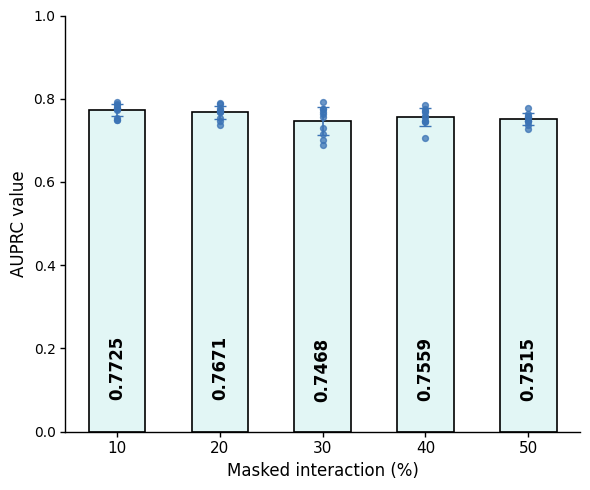

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================
# 1) 读入五个删边比例的结果
# =============================
base_dir = "./seed51"
ratios = [10, 20, 30, 40, 50]

bar_means = []
fold_values_list = []

for r in ratios:
    csv_path = os.path.join(base_dir, f"full_drop{r}", "outer_test_results_summary.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Missing file: {csv_path}")

    df = pd.read_csv(csv_path)

    # fold 列里 Mean 为总体均值，其余为各折
    df_folds = df[df["fold"] != "Mean"]
    df_mean  = df[df["fold"] == "Mean"].iloc[0]

    fold_vals = df_folds["test_auprc"].astype(float).values
    mean_val  = float(df_mean["test_auprc"])

    fold_values_list.append(fold_vals)
    bar_means.append(mean_val)

bar_means = np.array(bar_means)

# =============================
# 2) 作图参数
# =============================
x = np.arange(len(ratios))
bar_color   = "#e2f6f5"   
point_color = "#3b73b5"   # 点/误差棒颜色

fig, ax = plt.subplots(figsize=(6, 5))

# =============================
# 3) 柱状图（mean AUPRC）
# =============================
bars = ax.bar(
    x,
    bar_means,
    width=0.55,
    color=bar_color,
    edgecolor="black",   # 加回黑色边框
    linewidth=1.2,       # 边框粗细
    zorder=1
)

# =============================
# 4) 散点 + 误差棒 + 柱内竖向数字（无黑底）
# =============================
for i, folds in enumerate(fold_values_list):
    # 所有点的 x 坐标一致
    xi = np.full_like(folds, x[i], dtype=float)

    ax.scatter(
        xi,
        folds,
        s=18,
        color=point_color,
        alpha=0.75,
        zorder=3
    )

    # 均值 ± 标准差误差棒
    ax.errorbar(
        x[i],
        bar_means[i],
        yerr=np.std(folds),
        fmt='none',
        ecolor=point_color,
        elinewidth=1.2,
        capsize=4,
        zorder=4
    )

    # ---- 柱内竖向数字（无黑底）----
    y_text = bar_means[i] * 0.20  # 放在柱子下部
    ax.text(
        x[i],
        y_text,
        f"{bar_means[i]:.4f}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        rotation=90,
        color="black",
        zorder=5
    )

# =============================
# 5) 坐标轴与标签
# =============================
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in ratios], fontsize=11)
ax.set_xlabel("Masked interaction (%)", fontsize=12)
ax.set_ylabel("AUPRC value", fontsize=12)
ax.set_ylim(0, 1.0)

# 去掉上/右边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 左/下边框稍微细一点
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)

ax.tick_params(axis='both', width=1.0)

plt.tight_layout()

# =============================
# 6) 保存结果（SVG + PDF + 600dpi PNG）
# =============================
out_dir = "./figure"
os.makedirs(out_dir, exist_ok=True)

pdf_path = os.path.join(out_dir, "mask_bar_auprc.pdf")
fig.savefig(pdf_path, bbox_inches="tight")

print("Saved:")
print(" -", pdf_path)

plt.show()

In [9]:
# Cell 5: 按临床组做单次划分训练 & 评估（10个临床组循环）

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, accuracy_score, recall_score
)

# ========= 0) 生成“只保留某个临床组”的 x_dict（150维保持不变） =========
def build_xdict_keep_one_group(x_dict: dict, keep_group: int, step: int = 15, num_groups: int = 10):
    """
    150维特征按 step=15 分组，组内索引为 [g, g+15, ..., g+15*(num_groups-1)] 共10维。
    只保留 keep_group 对应的10个维度，其余维度置0，输入维度仍是150。
    """
    keep_idx = torch.tensor([keep_group + step*k for k in range(num_groups)], dtype=torch.long)
    out = {}
    for ntype, x in x_dict.items():
        x_new = torch.zeros_like(x)
        x_new[:, keep_idx] = x[:, keep_idx]
        out[ntype] = x_new
    return out, keep_idx.tolist()


# ========= 1) 检查标签 =========
if 'y' not in hetero_data['protein']:
    raise ValueError("protein 节点缺少标签 y，请在 hetero_data['protein'].y 中提供标签（0/1，未标注可为-1）。")

protein_y = hetero_data['protein'].y.view(-1)  # CPU
labeled_mask = protein_y >= 0
labeled_idx = labeled_mask.nonzero(as_tuple=False).view(-1)  # CPU
labeled_y = protein_y[labeled_idx].cpu().numpy()

print(f"Total protein nodes     : {hetero_data['protein'].num_nodes}")
print(f"Labeled protein nodes   : {labeled_idx.numel()}")

# ========= 2) 一次划分：Train/Test = 75/25 =========
outer_test_size = 0.25
train_all_idx_np, test_idx_np, train_all_y, test_y = train_test_split(
    labeled_idx.cpu().numpy(),
    labeled_y,
    test_size=outer_test_size,
    stratify=labeled_y,
    random_state=51
)

print(f"Outer train size (labeled): {len(train_all_idx_np)}")
print(f"Outer test  size (labeled): {len(test_idx_np)}")

# ========= 3) 在 Train 内再划分一次：Train/Val = 80/20（用于早停） =========
val_size = 0.2
train_idx_np, val_idx_np, train_y, val_y = train_test_split(
    train_all_idx_np,
    train_all_y,
    test_size=val_size,
    stratify=train_all_y,
    random_state=51
)

train_nodes = torch.from_numpy(train_idx_np)  # CPU
val_nodes   = torch.from_numpy(val_idx_np)    # CPU
test_nodes  = torch.from_numpy(test_idx_np)   # CPU

print(f"Inner train size: {train_nodes.numel()} | val size: {val_nodes.numel()}")

# ========= 4) 消融模式 & metadata=========
ABLATION_MODE = 'full'   
metadata = make_metadata(ABLATION_MODE)
node_types = metadata[0]

# ========= 5) 图和标签搬到 device（x_dict 每个clinical组会重新生成再搬） =========
hetero_data_device = hetero_data.to(device)

# ========= 6) 训练配置 =========
patience = 30
max_epochs = 300

# 保存总目录（再按 clinical_i 子目录分开）
base_save_dir = f". /once_results_MRAGDM_{ABLATION_MODE}_clinical10"
os.makedirs(base_save_dir, exist_ok=True)
print("Base results dir:", base_save_dir)

all_group_results = []

# ========= 7) 循环跑 10 个临床组 =========
for g in range(10):
    print(f"\n==============================")
    print(f"   Clinical Group {g} 训练开始")
    print(f"==============================")

    # 7.1 构造该组的 x_dict（150维不变，只保留该组10维）
    x_dict_g_cpu, keep_dims = build_xdict_keep_one_group(x_dict, keep_group=g, step=15, num_groups=10)

    # 搬到 device
    x_dict_device = {k: v.to(device) for k, v in x_dict_g_cpu.items()}

    # 7.2 每组单独目录
    save_dir = os.path.join(base_save_dir, f"clinical_{g}")
    os.makedirs(save_dir, exist_ok=True)
    print("Keep dims:", keep_dims)
    print("Save dir :", save_dir)

    # 7.3 初始化模型
    encoder = MRAGDM(
        metadata=metadata,
        in_dims=in_dims,
        hidden_dim=64,
        out_dim=48,
        num_layers=2,
        node_types=node_types,
        use_diffusion=True,
        diffusion_steps=10,
        diffusion_alpha=0.2
    ).to(device)

    model = ProteinClassifier(encoder, hidden_dim=64, num_classes=2, target_ntype='protein').to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-5)

    history = []
    best_auprc = 0.0
    best_state_dict = None
    best_epoch = 0
    best_val_metrics = None  # (acc, auroc, auprc, f1, recall)

    # ========= 7.4 训练（只跑一次 train/val） =========
    for epoch in range(1, max_epochs + 1):
        # ----- Train -----
        model.train()
        optimizer.zero_grad()

        logits, _ = model(x_dict_device, hetero_data_device)  # [N_protein, 2]
        train_logits = logits[train_nodes.to(device)]
        train_labels = protein_y[train_nodes].to(device).long()

        loss = F.cross_entropy(train_logits, train_labels)
        loss.backward()
        optimizer.step()

        # ----- Val -----
        model.eval()
        with torch.no_grad():
            logits_eval, _ = model(x_dict_device, hetero_data_device)
            val_logits = logits_eval[val_nodes.to(device)]
            val_prob = F.softmax(val_logits, dim=-1)[:, 1].cpu().numpy()
            val_true = protein_y[val_nodes].cpu().numpy().astype(int)
            val_pred = (val_prob >= 0.5).astype(int)

            try:
                val_auroc = roc_auc_score(val_true, val_prob)
            except ValueError:
                val_auroc = 0.0
            val_auprc = average_precision_score(val_true, val_prob)
            val_f1 = f1_score(val_true, val_pred)
            val_acc = accuracy_score(val_true, val_pred)
            val_recall = recall_score(val_true, val_pred, zero_division=0)

        history.append({
            'epoch': epoch,
            'train_loss': float(loss.item()),
            'val_acc': float(val_acc),
            'val_auroc': float(val_auroc),
            'val_auprc': float(val_auprc),
            'val_f1': float(val_f1),
            'val_recall': float(val_recall),
        })

        # ----- Early stop by Val AUPRC -----
        if val_auprc > best_auprc + 1e-6:
            best_auprc = val_auprc
            best_state_dict = {k: v.cpu() for k, v in model.state_dict().items()}
            best_epoch = epoch
            best_val_metrics = (val_acc, val_auroc, val_auprc, val_f1, val_recall)
        else:
            if epoch - best_epoch >= patience:
                print(f"Early stopping at epoch {epoch}, no AUPRC improvement for {patience} epochs.")
                break

        if epoch % 10 == 0 or epoch == 1:
            print(f"[G{g}] Epoch {epoch:03d} | Loss {loss.item():.4f} | "
                  f"Val AUPRC {val_auprc:.4f} | Val AUROC {val_auroc:.4f} | "
                  f"Val F1 {val_f1:.4f} | Val ACC {val_acc:.4f} | Val Recall {val_recall:.4f}")

    # ========= 7.5 用 best 模型在 test 上评估 + 保存 =========
    if best_state_dict is None:
        print(f"[G{g}] WARNING: no best_state_dict, skip.")
        continue

    print(f"[G{g}] Best Val AUPRC={best_auprc:.4f} at epoch {best_epoch}")

    # 重建并加载 best
    encoder_best = MRAGDM(
        metadata=metadata,
        in_dims=in_dims,
        hidden_dim=64,
        out_dim=48,
        num_layers=2,
        node_types=node_types,
        use_diffusion=True,
        diffusion_steps=10,
        diffusion_alpha=0.2
    ).to(device)

    model_best = ProteinClassifier(encoder_best, hidden_dim=64, num_classes=2, target_ntype='protein').to(device)
    model_best.load_state_dict({k: v.to(device) for k, v in best_state_dict.items()})
    model_best.eval()

    with torch.no_grad():
        logits_all, _ = model_best(x_dict_device, hetero_data_device)  # [N_protein,2]
        prob_all_t = F.softmax(logits_all, dim=-1)[:, 1]               # 原始概率(评估用)
        prob_all = prob_all_t.cpu().numpy()

        # （可选）仅用于画图的固定点放缩：不改变0.5两侧归属
        gamma = 0.6
        p = prob_all_t.clamp(0.0, 1.0)
        p_scaled = p.clone()
        left_mask = (p <= 0.5)
        right_mask = ~left_mask
        p_scaled[left_mask]  = 0.5 * ((p[left_mask] / 0.5).pow(gamma))
        p_scaled[right_mask] = 1.0 - 0.5 * (((1.0 - p[right_mask]) / 0.5).pow(gamma))
        prob_all_scaled = p_scaled.cpu().numpy()  # 写文件/画图用

        # Test 评估仍用原始 prob_all
        test_prob = prob_all[test_idx_np]
        test_true = test_y.astype(int)
        test_pred = (test_prob >= 0.5).astype(int)

        try:
            test_auroc = roc_auc_score(test_true, test_prob)
        except ValueError:
            test_auroc = 0.0
        test_auprc = average_precision_score(test_true, test_prob)
        test_f1 = f1_score(test_true, test_pred)
        test_acc = accuracy_score(test_true, test_pred)
        test_recall = recall_score(test_true, test_pred, zero_division=0)

    print(f"[G{g}] Test ACC={test_acc:.4f} | AUROC={test_auroc:.4f} | "
          f"AUPRC={test_auprc:.4f} | F1={test_f1:.4f} | Recall={test_recall:.4f}")

    # 记录结果
    all_group_results.append({
        'clinical_group': g,
        'keep_dims': str(keep_dims),
        'best_epoch': int(best_epoch),
        'val_acc': float(best_val_metrics[0]),
        'val_auroc': float(best_val_metrics[1]),
        'val_auprc': float(best_val_metrics[2]),
        'val_f1': float(best_val_metrics[3]),
        'val_recall': float(best_val_metrics[4]),
        'test_acc': float(test_acc),
        'test_auroc': float(test_auroc),
        'test_auprc': float(test_auprc),
        'test_f1': float(test_f1),
        'test_recall': float(test_recall),
    })

    # 保存 best 模型
    model_path = os.path.join(save_dir, f"best_model_G{g}_testAUPRC{test_auprc:.4f}.pt")
    torch.save(best_state_dict, model_path)

    # 保存全部 protein 预测（scaled 仅用于画图/文件；评估已用原始prob_all）
    df_pred = pd.DataFrame({
        'protein_node_id': np.arange(hetero_data['protein'].num_nodes),
        'prob_cancer': prob_all_scaled,
        'label': protein_y.cpu().numpy()
    })
    df_pred_path = os.path.join(save_dir, f"best_all_protein_predictions_G{g}.csv")
    df_pred.to_csv(df_pred_path, index=False)

    # 保存训练 history
    df_hist = pd.DataFrame(history)
    df_hist_path = os.path.join(save_dir, f"train_history_G{g}.csv")
    df_hist.to_csv(df_hist_path, index=False)

# ========= 8) 汇总10组结果 =========
df_all = pd.DataFrame(all_group_results)
summary_path = os.path.join(base_save_dir, "clinical10_summary.csv")
df_all.to_csv(summary_path, index=False)

print("\n========== Clinical10 Summary (one-run each) ==========")
print(df_all[['clinical_group','test_auprc','test_auroc','test_f1','test_acc','test_recall']])
print("Saved summary to:", summary_path)


Total protein nodes     : 18326
Labeled protein nodes   : 2856
Outer train size (labeled): 2142
Outer test  size (labeled): 714
Inner train size: 1713 | val size: 429
[full] edge_types used:
    ('lncrna', 'lncrnaTOlncrna', 'lncrna')
    ('lncrna', 'lncrnaTOmirna', 'mirna')
    ('lncrna', 'lncrnaTOprotein', 'protein')
    ('mirna', 'mirnaTOlncrna', 'lncrna')
    ('mirna', 'mirnaTOmirna', 'mirna')
    ('mirna', 'mirnaTOprotein', 'protein')
    ('protein', 'proteinTOlncrna', 'lncrna')
    ('protein', 'proteinTOmirna', 'mirna')
    ('protein', 'proteinTOprotein', 'protein')
Base results dir: . /once_results_MRAGDM_full_clinical10

   Clinical Group 0 训练开始
Keep dims: [0, 15, 30, 45, 60, 75, 90, 105, 120, 135]
Save dir : . /once_results_MRAGDM_full_clinical10/clinical_0
[G0] Epoch 001 | Loss 0.6066 | Val AUPRC 0.5008 | Val AUROC 0.6924 | Val F1 0.0000 | Val ACC 0.7249 | Val Recall 0.0000
[G0] Epoch 010 | Loss 0.5174 | Val AUPRC 0.5466 | Val AUROC 0.7512 | Val F1 0.5301 | Val ACC 0.7273 | Va

=== 每组 label==1 总数（检查用）===
         Age: 788
      Gender: 788
           M: 788
           N: 788
      OStime: 788
       Stage: 788
      Status: 788
   Treatment: 788
TumorvsNormal: 788
           T: 788

=== 环状图：label==1 且 prob>0.5 的数量 ===
         Age: 455
      Gender: 462
           M: 534
           N: 554
      OStime: 456
       Stage: 557
      Status: 459
   Treatment: 579
TumorvsNormal: 580
           T: 537
Total = 5173


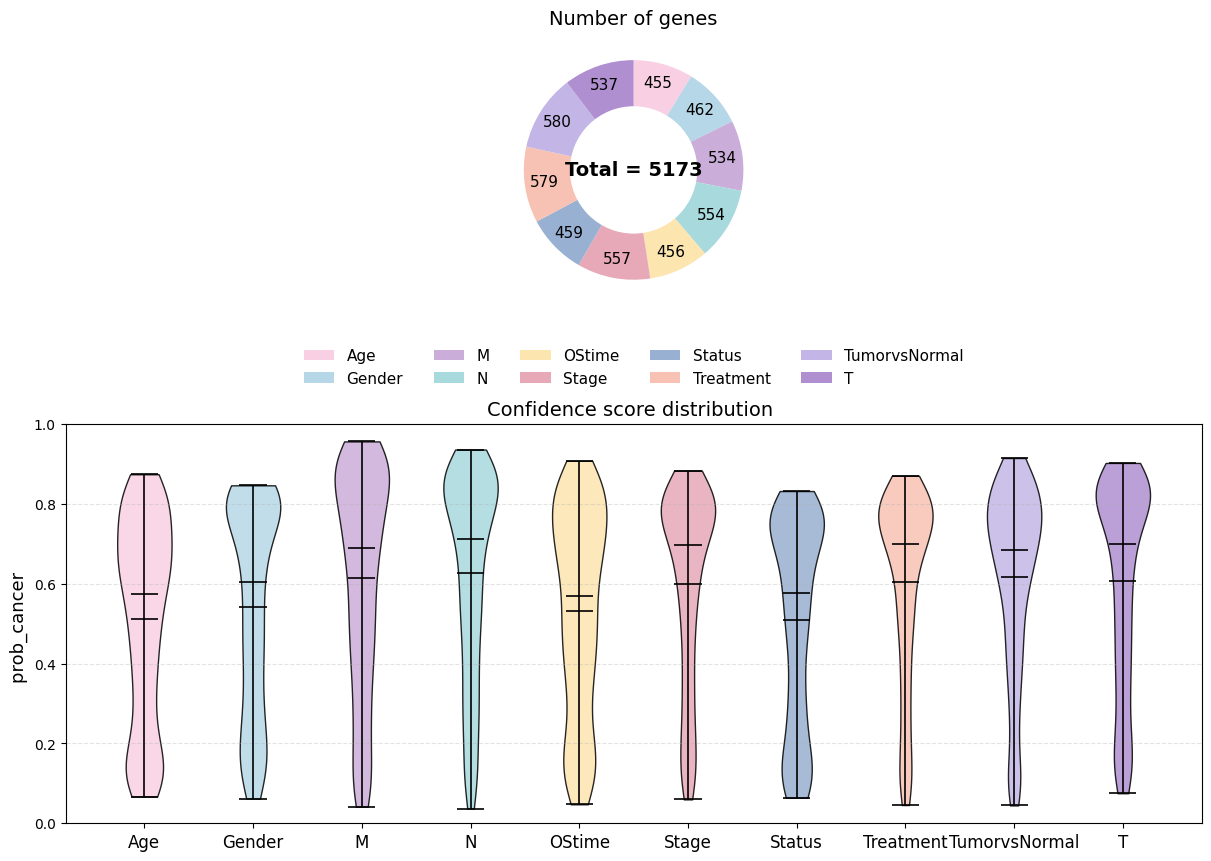

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== 10个结果所在的总目录 ======
# 例如：/root/autodl-tmp/diff_autodl/once_results_MRAGDM_full_clinical10
base_dir = "./once_results_MRADiff_full_clinical10"

# ====== 临床指标名（顺序对应 clinical_0 ... clinical_9） ======
clinical_names = [
    "Age", "Gender", "M", "N", "OStime",
    "Stage", "Status", "Treatment", "TumorvsNormal", "T"
]

# ====== 自动寻找每组csv路径 ======
# 兼容你的命名：clinical_0/best_all_protein_predictions_G0.csv
csv_paths = []
for g in range(10):
    p = os.path.join(base_dir, f"clinical_{g}", f"best_all_protein_predictions_G{g}.csv")
    if not os.path.exists(p):
        # 兜底：用glob找
        cand = glob.glob(os.path.join(base_dir, f"clinical_{g}", "best_all_protein_predictions*.csv"))
        if len(cand) == 0:
            raise FileNotFoundError(f"找不到 clinical_{g} 的预测文件，请检查目录：{os.path.join(base_dir, f'clinical_{g}')} ")
        p = cand[0]
    csv_paths.append(p)

# ====== 读取汇总：counts & violin_values ======
counts_pred_pos = []   # 环状图用：label==1 且 prob>0.5 的数量
violin_values = []     # 小提琴用：label==1 的 prob 全部
pos_total = []         # 每组 label==1 的总数（用于检查）
for name, path in zip(clinical_names, csv_paths):
    df = pd.read_csv(path)

    # 只取label==1
    df_pos = df[df["label"] == 1]
    probs = df_pos["prob_cancer"].astype(float).dropna().values

    violin_values.append(probs)
    pos_total.append(len(probs))

    # label==1 中 prob>0.5 的数量
    counts = int((probs > 0.5).sum())
    counts_pred_pos.append(counts)

print("=== 每组 label==1 总数（检查用）===")
for n, t in zip(clinical_names, pos_total):
    print(f"{n:>12s}: {t}")

print("\n=== 环状图：label==1 且 prob>0.5 的数量 ===")
for n, c in zip(clinical_names, counts_pred_pos):
    print(f"{n:>12s}: {c}")
print("Total =", sum(counts_pred_pos))

# ===== 柔和配色（10个）=====
colors = [
    "#F9D0E3",
    "#B6D7E7",
    "#CAADD8",
    "#A7D9DD",
    "#FDE5B0",
    "#E7A8B8",
    "#98B0D1",
    "#F7C2B3",
    "#C3B6E6",
    "#AF8FD0"
]

# 关键：用 constrained_layout 自动避免重叠（比 tight_layout 更稳）
fig = plt.figure(figsize=(12, 8.5), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[1.1, 1.6])

# ======================
# 上：环状图
# ======================
ax0 = fig.add_subplot(gs[0, 0])

vals = np.array(counts_pred_pos, dtype=float)
total = vals.sum()
if total <= 0:
    vals = np.ones_like(vals)
    total = vals.sum()

wedges, _, _ = ax0.pie(
    vals,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct=lambda p: f"{int(round(p*total/100.0))}" if p > 0 else "",
    pctdistance=0.82,
    textprops={"fontsize":11}
)

# 环形
centre_circle = plt.Circle((0, 0), 0.58, fc="white")
ax0.add_artist(centre_circle)

ax0.text(
    0, 0,
    f"Total = {int(sum(counts_pred_pos))}",
    ha="center", va="center",
    fontsize=14, fontweight="bold"
)

ax0.set_title("Number of genes", fontsize=14)
ax0.set_aspect("equal")

# 图例：放在环状图下面，独占一行，避免压到下方小提琴
ax0.legend(
    wedges, clinical_names,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),   # 往下挪一点
    ncol=5,
    frameon=False,
    fontsize=11
)

# ======================
# 下：小提琴图
# ======================
ax1 = fig.add_subplot(gs[1, 0])

parts = ax1.violinplot(
    violin_values,
    showmeans=True,
    showmedians=True,
    showextrema=True
)

# 每个小提琴上色
for i, body in enumerate(parts['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor("black")
    body.set_alpha(0.85)

# 线条统一
for key in ['cmeans', 'cmedians', 'cbars', 'cmins', 'cmaxes']:
    parts[key].set_edgecolor("black")
    parts[key].set_linewidth(1.2)

ax1.set_xticks(np.arange(1, len(clinical_names) + 1))
ax1.set_xticklabels(clinical_names, fontsize=12)

ax1.set_ylabel("prob_cancer ", fontsize=13)
ax1.set_title("Confidence score distribution ", fontsize=14)

# 不截断：显示完整 0~1
ax1.set_ylim(0.0, 1.0)

ax1.grid(axis="y", linestyle="--", alpha=0.35)
pdf_path = os.path.join('./figure', "cli_impor.pdf")
plt.savefig(
    pdf_path,
    bbox_inches='tight',
    dpi=300,
    backend='pdf'
)
plt.show()


In [7]:
import matplotlib.pyplot as plt

ABLATION_MODE = "full"  
MODEL_PATH = "./seed51/full/best_model_fold9_testAUPRC0.7888.pt"  # 最佳模型路径

# metadata 必须与训练时一致
metadata = make_metadata(ABLATION_MODE)
node_types = metadata[0]

# 构建同结构模型
encoder_best = MRAGDM(
    metadata=metadata,
    in_dims=in_dims,
    hidden_dim=64,
    out_dim=48,
    num_layers=2,
    node_types=node_types,
    use_diffusion=True,
    diffusion_steps=10,
    diffusion_alpha=0.2
).to(device)

model_best = ProteinClassifier(
    encoder_best,
    hidden_dim=64,
    num_classes=2,
    target_ntype='protein'
).to(device)

# 载入权重
state = torch.load(MODEL_PATH, map_location="cpu")
missing, unexpected = model_best.load_state_dict(
    {k: v.to(device) for k, v in state.items()},
    strict=False
)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
model_best.eval()

# 数据搬到 device
hetero_data_device = hetero_data.to(device)
x_dict_device = {k: v.to(device) for k, v in x_dict.items()}

print("Loaded model from:", MODEL_PATH)


[full] edge_types used:
    ('lncrna', 'lncrnaTOlncrna', 'lncrna')
    ('lncrna', 'lncrnaTOmirna', 'mirna')
    ('lncrna', 'lncrnaTOprotein', 'protein')
    ('mirna', 'mirnaTOlncrna', 'lncrna')
    ('mirna', 'mirnaTOmirna', 'mirna')
    ('mirna', 'mirnaTOprotein', 'protein')
    ('protein', 'proteinTOlncrna', 'lncrna')
    ('protein', 'proteinTOmirna', 'mirna')
    ('protein', 'proteinTOprotein', 'protein')
Missing keys: []
Unexpected keys: []
Loaded model from: ./seed51/full/best_model_fold9_testAUPRC0.7888.pt


In [8]:
from torch_geometric.data import HeteroData

HET_PATH = os.path.join(".", "data", "hetero_data.pt")
data_obj = torch.load(HET_PATH)

if isinstance(data_obj, HeteroData):
    hetero_data = data_obj
elif isinstance(data_obj, dict) and 'hetero_data' in data_obj:
    hetero_data = data_obj['hetero_data']
else:
    raise ValueError("无法识别 hetero_data 格式，请确认 hetero_data.pt 里存的是 HeteroData 或 {'hetero_data': HeteroData}.")

print(hetero_data)

node_types, edge_types = hetero_data.metadata()
print("Node types:", node_types)
print("Edge types:", edge_types)

in_dims = {ntype: hetero_data[ntype].x.size(1) for ntype in node_types}
print("Input dims per node type:", in_dims)

# x_dict（先留在CPU）
x_dict = {ntype: hetero_data[ntype].x.clone() for ntype in node_types}

# label
if 'y' not in hetero_data['protein']:
    raise ValueError("protein 节点缺少标签 y，请在 hetero_data['protein'].y 中提供标签（0/1，未标注可为-1）。")

protein_y = hetero_data['protein'].y.view(-1)  # CPU
labeled_mask = protein_y >= 0
labeled_idx = labeled_mask.nonzero(as_tuple=False).view(-1)
print("Total protein:", hetero_data['protein'].num_nodes)
print("Labeled protein:", labeled_idx.numel())


HeteroData(
  protein={
    x=[18326, 150],
    y=[18326],
  },
  lncrna={ x=[1811, 150] },
  mirna={ x=[1589, 150] },
  (lncrna, lncrnaTOlncrna, lncrna)={ edge_index=[2, 296] },
  (lncrna, lncrnaTOmirna, mirna)={ edge_index=[2, 7277] },
  (lncrna, lncrnaTOprotein, protein)={ edge_index=[2, 10376] },
  (mirna, mirnaTOlncrna, lncrna)={ edge_index=[2, 7277] },
  (mirna, mirnaTOmirna, mirna)={ edge_index=[2, 158] },
  (mirna, mirnaTOprotein, protein)={ edge_index=[2, 510229] },
  (protein, proteinTOlncrna, lncrna)={ edge_index=[2, 10376] },
  (protein, proteinTOmirna, mirna)={ edge_index=[2, 510229] },
  (protein, proteinTOprotein, protein)={ edge_index=[2, 939078] }
)
Node types: ['protein', 'lncrna', 'mirna']
Edge types: [('lncrna', 'lncrnaTOlncrna', 'lncrna'), ('lncrna', 'lncrnaTOmirna', 'mirna'), ('lncrna', 'lncrnaTOprotein', 'protein'), ('mirna', 'mirnaTOlncrna', 'lncrna'), ('mirna', 'mirnaTOmirna', 'mirna'), ('mirna', 'mirnaTOprotein', 'protein'), ('protein', 'proteinTOlncrna', 'lnc

In [15]:
feature_names_str = r"""Age_TCGA-BRCA	Gender_TCGA-BRCA	M_TCGA-BRCA	N_TCGA-BRCA	OStime_TCGA-BRCA	Stage_TCGA-BRCA	Status_TCGA-BRCA	Treatment_TCGA-BRCA	TumorvsNormal_TCGA-BRCA	T_TCGA-BRCA	Age_TCGA-CESC	Gender_TCGA-CESC	M_TCGA-CESC	N_TCGA-CESC	OStime_TCGA-CESC	Stage_TCGA-CESC	Status_TCGA-CESC	Treatment_TCGA-CESC	TumorvsNormal_TCGA-CESC	T_TCGA-CESC	Age_TCGA-CHOL	Gender_TCGA-CHOL	M_TCGA-CHOL	N_TCGA-CHOL	OStime_TCGA-CHOL	Stage_TCGA-CHOL	Status_TCGA-CHOL	Treatment_TCGA-CHOL	TumorvsNormal_TCGA-CHOL	T_TCGA-CHOL	Age_TCGA-DLBC	Gender_TCGA-DLBC	M_TCGA-DLBC	N_TCGA-DLBC	OStime_TCGA-DLBC	Stage_TCGA-DLBC	Status_TCGA-DLBC	Treatment_TCGA-DLBC	TumorvsNormal_TCGA-DLBC	T_TCGA-DLBC	Age_TCGA-ESCA	Gender_TCGA-ESCA	M_TCGA-ESCA	N_TCGA-ESCA	OStime_TCGA-ESCA	Stage_TCGA-ESCA	Status_TCGA-ESCA	Treatment_TCGA-ESCA	TumorvsNormal_TCGA-ESCA	T_TCGA-ESCA	Age_TCGA-HNSC	Gender_TCGA-HNSC	M_TCGA-HNSC	N_TCGA-HNSC	OStime_TCGA-HNSC	Stage_TCGA-HNSC	Status_TCGA-HNSC	Treatment_TCGA-HNSC	TumorvsNormal_TCGA-HNSC	T_TCGA-HNSC	Age_TCGA-LAML	Gender_TCGA-LAML	M_TCGA-LAML	N_TCGA-LAML	OStime_TCGA-LAML	Stage_TCGA-LAML	Status_TCGA-LAML	Treatment_TCGA-LAML	TumorvsNormal_TCGA-LAML	T_TCGA-LAML	Age_TCGA-LIHC	Gender_TCGA-LIHC	M_TCGA-LIHC	N_TCGA-LIHC	OStime_TCGA-LIHC	Stage_TCGA-LIHC	Status_TCGA-LIHC	Treatment_TCGA-LIHC	TumorvsNormal_TCGA-LIHC	T_TCGA-LIHC	Age_TCGA-LUAD	Gender_TCGA-LUAD	M_TCGA-LUAD	N_TCGA-LUAD	OStime_TCGA-LUAD	Stage_TCGA-LUAD	Status_TCGA-LUAD	Treatment_TCGA-LUAD	TumorvsNormal_TCGA-LUAD	T_TCGA-LUAD	Age_TCGA-OV	Gender_TCGA-OV	M_TCGA-OV	N_TCGA-OV	OStime_TCGA-OV	Stage_TCGA-OV	Status_TCGA-OV	Treatment_TCGA-OV	TumorvsNormal_TCGA-OV	T_TCGA-OV	Age_TCGA-PAAD	Gender_TCGA-PAAD	M_TCGA-PAAD	N_TCGA-PAAD	OStime_TCGA-PAAD	Stage_TCGA-PAAD	Status_TCGA-PAAD	Treatment_TCGA-PAAD	TumorvsNormal_TCGA-PAAD	T_TCGA-PAAD	Age_TCGA-PRAD	Gender_TCGA-PRAD	M_TCGA-PRAD	N_TCGA-PRAD	OStime_TCGA-PRAD	Stage_TCGA-PRAD	Status_TCGA-PRAD	Treatment_TCGA-PRAD	TumorvsNormal_TCGA-PRAD	T_TCGA-PRAD	Age_TCGA-STAD	Gender_TCGA-STAD	M_TCGA-STAD	N_TCGA-STAD	OStime_TCGA-STAD	Stage_TCGA-STAD	Status_TCGA-STAD	Treatment_TCGA-STAD	TumorvsNormal_TCGA-STAD	T_TCGA-STAD	Age_TCGA-THCA	Gender_TCGA-THCA	M_TCGA-THCA	N_TCGA-THCA	OStime_TCGA-THCA	Stage_TCGA-THCA	Status_TCGA-THCA	Treatment_TCGA-THCA	TumorvsNormal_TCGA-THCA	T_TCGA-THCA	Age_TCGA-UVM	Gender_TCGA-UVM	M_TCGA-UVM	N_TCGA-UVM	OStime_TCGA-UVM	Stage_TCGA-UVM	Status_TCGA-UVM	Treatment_TCGA-UVM	TumorvsNormal_TCGA-UVM	T_TCGA-UVM"""

# 以空白/Tab 分割成 list
feature_names = feature_names_str.split()
print("num feature names:", len(feature_names))

# 检查维度一致
assert hetero_data['protein'].x.size(1) == len(feature_names), \
    f"protein.x dim={hetero_data['protein'].x.size(1)} != feature_names={len(feature_names)}"

clinical_factors = ["Age","Gender","M","N","OStime","Stage","Status","Treatment","TumorvsNormal","T"]

# 从 feature_names 自动抽癌种列表（如 BRCA/CESC/...）
cancer_set = []
for fn in feature_names:
    # fn like "Age_TCGA-BRCA"
    if "TCGA-" in fn:
        cancer = fn.split("TCGA-")[-1]
        if cancer not in cancer_set:
            cancer_set.append(cancer)

print("cancers:", cancer_set)
print("num cancers:", len(cancer_set))

# 建一个名字->列索引的映射
name_to_idx = {n:i for i,n in enumerate(feature_names)}

# 每个癌种 10 个因子对应的列索引
cancer_factor_indices = {}
for cancer in cancer_set:
    idxs = []
    for fac in clinical_factors:
        key = f"{fac}_TCGA-{cancer}"
        if key not in name_to_idx:
            raise KeyError(f"特征名缺失：{key}")
        idxs.append(name_to_idx[key])
    cancer_factor_indices[cancer] = idxs

# 看一眼 BRCA 的 10 维索引
print("BRCA indices:", cancer_factor_indices.get("BRCA", None))


num feature names: 150
cancers: ['BRCA', 'CESC', 'CHOL', 'DLBC', 'ESCA', 'HNSC', 'LAML', 'LIHC', 'LUAD', 'OV', 'PAAD', 'PRAD', 'STAD', 'THCA', 'UVM']
num cancers: 15
BRCA indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [10]:
def get_target_nodes(mode="label1"):
    """
    mode:
      - "label1": 所有 y=1 的标注节点
      - "label1_prob05": y=1 且当前模型预测 prob>0.5 的节点
    """
    y = protein_y  # CPU
    pos_nodes = (y == 1).nonzero(as_tuple=False).view(-1)
    if mode == "label1":
        return pos_nodes.cpu().numpy()

    if mode == "label1_prob05":
        model_best.eval()
        with torch.no_grad():
            logits, _ = model_best(x_dict_device, hetero_data_device)
            prob = F.softmax(logits, dim=-1)[:, 1].detach().cpu()
        keep = prob[pos_nodes] > 0.5
        return pos_nodes[keep].cpu().numpy()

    raise ValueError("mode must be label1 or label1_prob05")


def compute_importance_15x10(model, x_dict_device, hetero_data_device,
                            cancer_set, cancer_factor_indices,
                            target_nodes_np,
                            use_grad_x_input=True):
    """
    返回：
      importance: dict[cancer] -> np.array(10,) 已归一化
    """
    model.eval()

    # protein 特征需要梯度
    x_prot = x_dict_device["protein"].clone().detach().requires_grad_(True)
    x_dict = dict(x_dict_device)
    x_dict["protein"] = x_prot

    # forward: 用 logit 更稳定
    logits, _ = model(x_dict, hetero_data_device)   # [N_protein,2]
    score = logits[:, 1]                            # cancer logit

    target_nodes = torch.from_numpy(target_nodes_np).to(device)
    s = score[target_nodes].mean()

    model.zero_grad(set_to_none=True)
    if x_prot.grad is not None:
        x_prot.grad.zero_()
    s.backward()

    grad = x_prot.grad.detach()     # [N,150]
    feat = x_prot.detach()          # [N,150]

    grad_t = grad[target_nodes]     # [M,150]
    feat_t = feat[target_nodes]     # [M,150]

    out = {}
    for cancer in cancer_set:
        idxs = cancer_factor_indices[cancer]  # 10 dims
        idxs_t = torch.tensor(idxs, device=device)

        if use_grad_x_input:
            # [M,10] -> sum over nodes -> 10
            val = (grad_t[:, idxs_t].abs() * feat_t[:, idxs_t].abs()).mean(dim=0)
        else:
            val = grad_t[:, idxs_t].abs().mean(dim=0)

        v = val.detach().cpu().numpy().astype(float)
        v = v / (v.sum() + 1e-12)  # 归一化占比
        out[cancer] = v

    return out


# ===== 选择目标节点集合 =====
TARGET_MODE = "label1"  # 或 "label1_prob05"
target_nodes_np = get_target_nodes(TARGET_MODE)
print("target nodes:", len(target_nodes_np), "mode:", TARGET_MODE)

importance_dict = compute_importance_15x10(
    model_best,
    x_dict_device,
    hetero_data_device,
    cancer_set,
    cancer_factor_indices,
    target_nodes_np,
    use_grad_x_input=True
)

# 转成 DataFrame: 15 x 10
df_imp = pd.DataFrame.from_dict(importance_dict, orient="index", columns=clinical_factors)
df_imp.index.name = "Cancer"
df_imp


target nodes: 788 mode: label1


,Age,Gender,M,N,OStime,Stage,Status,Treatment,TumorvsNormal,T
Cancer,,,,,,,,,,
BRCA,0.061519,0.231746,0.178942,0.098551,0.088030,0.046436,0.035018,0.012495,0.154952,0.092310
CESC,0.149842,0.000000,0.051867,0.057422,0.056852,0.000000,0.152732,0.053859,0.401122,0.076304
CHOL,0.078305,0.079367,0.110280,0.062027,0.034816,0.072637,0.067674,0.064753,0.270195,0.159947
DLBC,0.095156,0.289667,0.000000,0.000000,0.335175,0.000000,0.196201,0.083800,0.000000,0.000000
ESCA,0.359819,0.047122,0.126991,0.077220,0.070957,0.064883,0.142228,0.065170,0.000000,0.045609
HNSC,0.041599,0.188114,0.000000,0.067578,0.196755,0.095578,0.067210,0.021590,0.277310,0.044266
LAML,0.418527,0.054060,0.000000,0.000000,0.264863,0.000000,0.136699,0.125851,0.000000,0.000000
LIHC,0.108527,0.125911,0.224580,0.148240,0.032570,0.030651,0.099678,0.016437,0.158790,0.054616
LUAD,0.045282,0.048916,0.172712,0.107631,0.064418,0.062569,0.074343,0.062931,0.208199,0.152999


Saved: result/importance_15cancer_10clinical_51.csv


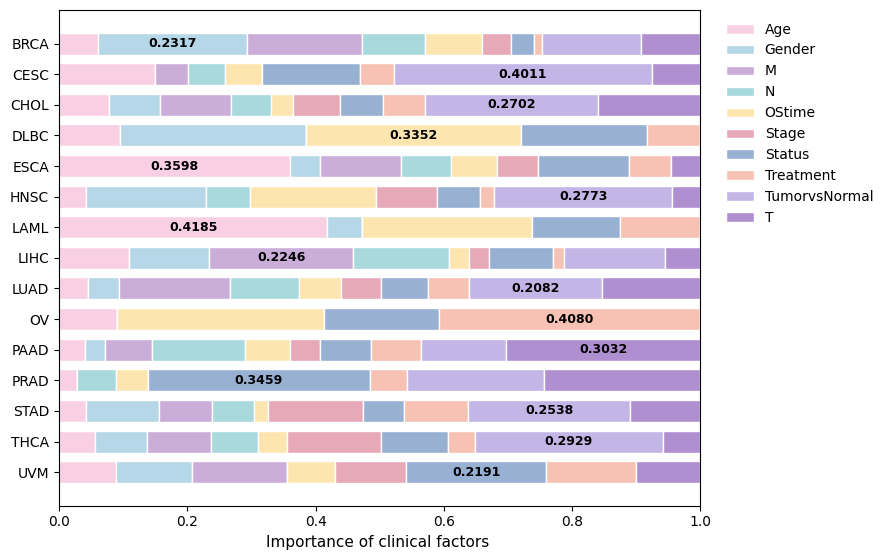

In [11]:
# 保存
out_csv = "result/importance_15cancer_10clinical_51.csv"
df_imp.to_csv(out_csv)
print("Saved:", out_csv)

# ===== 画 TREE Fig3 风格：数值标在最大块上 + legend 单列 =====

clinical_factors = [
    "Age","Gender","M","N","OStime",
    "Stage","Status","Treatment","TumorvsNormal","T"
]


colors = [
    "#F9D0E3",
    "#B6D7E7",
    "#CAADD8",
    "#A7D9DD",
    "#FDE5B0",
    "#E7A8B8",
    "#98B0D1",
    "#F7C2B3",
    "#C3B6E6",
    "#AF8FD0"
]


fig, ax = plt.subplots(figsize=(9, max(5, 0.38 * len(df_imp))))

y_names = df_imp.index.tolist()
left = np.zeros(len(df_imp))

# 记录每个癌种“最大块”的信息，用于标数字
max_vals = df_imp.max(axis=1).values                 # 最大占比
max_cols = df_imp.idxmax(axis=1).values              # 对应因子名

for j, fac in enumerate(clinical_factors):
    vals = df_imp[fac].values
    bars = ax.barh(
        y_names,
        vals,
        left=left,
        color=colors[j],
        edgecolor="white",
        height=0.72,
        label=fac
    )

    # === 如果这个 fac 是该癌种的最大块，就在块中间标数值 ===
    for i, (v, l) in enumerate(zip(vals, left)):
        if fac == max_cols[i]:
            ax.text(
                l + v / 2,
                i,
                f"{v:.4f}",
                va="center",
                ha="center",
                fontsize=9,
                fontweight="bold",
                color="black"
            )

    left += vals

# 轴与标题
ax.set_xlim(0, 1.0)
ax.set_xlabel("Importance of clinical factors ", fontsize=11)

ax.invert_yaxis()

# === 右上角：单列 legend ===
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    ncol=1,          # 单列
    fontsize=10
)

plt.tight_layout()
pdf_path = os.path.join('./figure', "can_impor.pdf")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()





In [9]:
# Cell 5: 构建模型

node_types = hetero_data.node_types
metadata = (hetero_data.node_types, hetero_data.edge_types)

# 输入维度字典（现在 protein/lncrna/mirna 都是 150 就会自动读出来）
in_dims = {ntype: x_dict[ntype].shape[1] for ntype in node_types}

hidden_dim = 64        
out_dim    = 48       
num_layers = 2          
use_diffusion = True
diffusion_steps = 10    
diffusion_alpha = 0.2   

encoder = MRAGDM(
    metadata=metadata,
    in_dims=in_dims,
    hidden_dim=hidden_dim,
    out_dim=out_dim,
    num_layers=num_layers,
    node_types=node_types,
    use_diffusion=use_diffusion,
    diffusion_steps=diffusion_steps,
    diffusion_alpha=diffusion_alpha
)

model = ProteinClassifier(encoder=encoder, hidden_dim=hidden_dim, num_classes=2, target_ntype="protein")
model = model.to(device)

# 加载 checkpoint
state = torch.load(MODEL_PATH, map_location=device)
missing, unexpected = model.load_state_dict(
    {k: v.to(device) for k, v in state.items()},
    strict=False
)
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))
model.eval()


Missing keys: 0
Unexpected keys: 0


ProteinClassifier(
  (encoder): MRAGDM(
    (input_proj): ModuleDict(
      (protein): Linear(in_features=150, out_features=64, bias=True)
      (lncrna): Linear(in_features=150, out_features=64, bias=True)
      (mirna): Linear(in_features=150, out_features=64, bias=True)
    )
    (layers): ModuleList(
      (0-1): 2 x MRAGDMLayer(
        (rel_convs): ModuleDict(
          (lncrna__lncrnaTOlncrna__lncrna): DiffusionRelConv()
          (lncrna__lncrnaTOmirna__mirna): DiffusionRelConv()
          (lncrna__lncrnaTOprotein__protein): DiffusionRelConv()
          (mirna__mirnaTOlncrna__lncrna): DiffusionRelConv()
          (mirna__mirnaTOmirna__mirna): DiffusionRelConv()
          (mirna__mirnaTOprotein__protein): DiffusionRelConv()
          (protein__proteinTOlncrna__lncrna): DiffusionRelConv()
          (protein__proteinTOmirna__mirna): DiffusionRelConv()
          (protein__proteinTOprotein__protein): DiffusionRelConv()
        )
        (coupling_attention): CouplingAttention(
     

In [11]:
# Cell 6: 准备输入（放到 device；并让 protein 特征可求梯度）
hetero_data_device = hetero_data.to(device)

x_dict_device = {k: v.to(device) for k, v in x_dict.items()}

# 复制一份用于求梯度（避免污染原始 x_dict）
x_dict_grad = {k: v.clone().detach() for k, v in x_dict_device.items()}
x_dict_grad["protein"].requires_grad_(True)

print("protein x requires_grad:", x_dict_grad["protein"].requires_grad)
print("protein x shape:", x_dict_grad["protein"].shape)


protein x requires_grad: True
protein x shape: torch.Size([18326, 150])


In [12]:
# Cell 7: 取出 788 个癌症基因 protein 节点索引（y==1）
protein_y = hetero_data_device["protein"].y.view(-1)
cancer_idx = (protein_y == 1).nonzero(as_tuple=False).view(-1)

print("Num protein:", hetero_data_device["protein"].num_nodes)
print("Num cancer genes (y==1):", cancer_idx.numel())


Num protein: 18326
Num cancer genes (y==1): 788


In [13]:
# Cell 8: 计算 788x150 特征重要性（Gradient × Input）
# 重要：不要用 torch.no_grad()，因为要梯度
model.zero_grad(set_to_none=True)

logits, _ = model(x_dict_grad, hetero_data_device)   # [N_protein, 2]
cancer_logit = logits[:, 1]                          # 取“癌症基因”这一类的 logit

# 目标：788 个癌症基因节点的 logit 求和
target = cancer_logit[cancer_idx].sum()

# 反向传播到输入特征
target.backward()

grad = x_dict_grad["protein"].grad                   # [N_protein, 150]
x_in = x_dict_grad["protein"].detach()               # [N_protein, 150]

attr_all = grad * x_in                               # [N_protein, 150]
attr_cancer = attr_all[cancer_idx]                   # [788, 150]

print("attr_cancer:", attr_cancer.shape, attr_cancer.dtype)


attr_cancer: torch.Size([788, 150]) torch.float32


In [16]:
import torch

save_path = "result/attr_cancer_788x150.pt"

save_obj = {
    "attr_cancer": attr_cancer.detach().cpu(),  # [788,150]
    "cancer_idx": cancer_idx.detach().cpu(),    # [788]
    "feature_names": feature_names,              # list[str], len=150
    "clinical_factors": clinical_factors         # list[str], len=10
}

torch.save(save_obj, save_path)
print("Saved to:", save_path)


Saved to: result/attr_cancer_788x150.pt


In [17]:
# Cell : 挑选突出基因
import torch
import numpy as np
from collections import defaultdict

# ===== 阈值=====
TH_MAIN = 0.45   # 至少一个 > 0.5
TH_OTHER = 0.40  # 其它所有 < 0.4

# ===== 1. 建立：临床因子 -> 列索引 =====
factor_to_cols = {fac: [] for fac in clinical_factors}

for j, fname in enumerate(feature_names):
    fac = fname.split("_TCGA-")[0]   # Age / Gender / ...
    if fac in factor_to_cols:
        factor_to_cols[fac].append(j)

# 简单检查
for fac in clinical_factors:
    print(f"{fac}: {len(factor_to_cols[fac])} cols")

# ===== 2. 开始筛选 =====
dominant_gene_dict = defaultdict(list)

attr_np = attr_cancer.detach().cpu().numpy()
cancer_idx_np = cancer_idx.detach().cpu().numpy()

for i in range(attr_np.shape[0]):          # 遍历 788 个基因
    row = attr_np[i]                       # [150]

    # 计算每个临床因子的 max 值
    fac_max = {}
    for fac in clinical_factors:
        cols = factor_to_cols[fac]
        fac_max[fac] = np.max(row[cols])

    # 找是否存在“主导因子”
    for fac in clinical_factors:
        if fac_max[fac] > TH_MAIN:
            # 其它所有因子必须 < TH_OTHER
            others_ok = True
            for other_fac in clinical_factors:
                if other_fac == fac:
                    continue
                if fac_max[other_fac] >= TH_OTHER:
                    others_ok = False
                    break

            if others_ok:
                dominant_gene_dict[fac].append(int(cancer_idx_np[i]))
                break   # 一个基因只归到一个主导因子

# ===== 3. 查看结果 =====
for fac in clinical_factors:
    print(f"{fac}: {len(dominant_gene_dict.get(fac, []))}")

dominant_gene_dict


Age: 15 cols
Gender: 15 cols
M: 15 cols
N: 15 cols
OStime: 15 cols
Stage: 15 cols
Status: 15 cols
Treatment: 15 cols
TumorvsNormal: 15 cols
T: 15 cols
Age: 3
Gender: 0
M: 1
N: 0
OStime: 5
Stage: 0
Status: 0
Treatment: 0
TumorvsNormal: 19
T: 5


defaultdict(list,
            {'TumorvsNormal': [895,
              1315,
              1617,
              3538,
              4628,
              4723,
              5039,
              6020,
              7450,
              7850,
              8151,
              9648,
              10069,
              11016,
              11984,
              12497,
              12724,
              13571,
              15010],
             'T': [1564, 2381, 12270, 13361, 17393],
             'M': [2222],
             'OStime': [7095, 8092, 11942, 12145, 16321],
             'Age': [8335, 9551, 14952]})

Cancer types: ['BRCA', 'CESC', 'CHOL', 'DLBC', 'ESCA', 'HNSC', 'LAML', 'LIHC', 'LUAD', 'OV', 'PAAD', 'PRAD', 'STAD', 'THCA', 'UVM']
Num cancers: 15


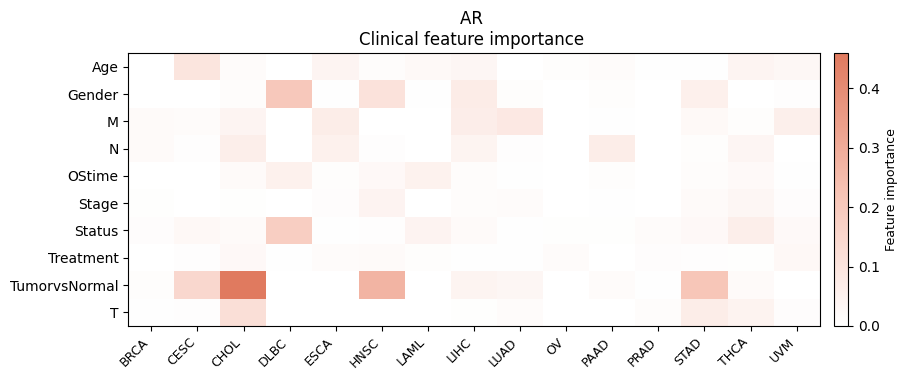

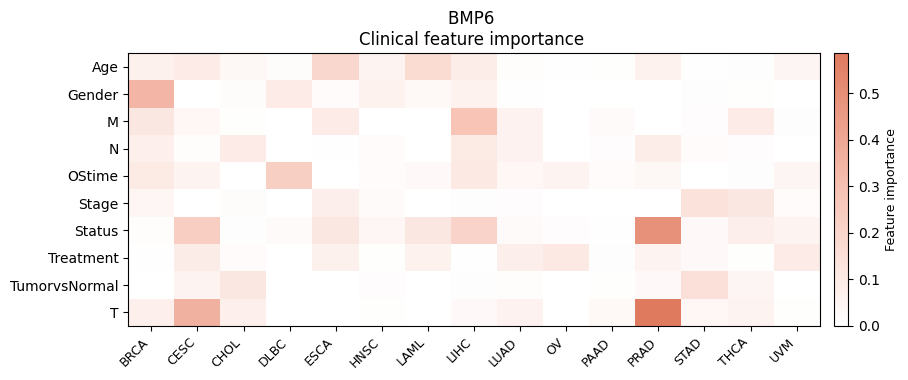

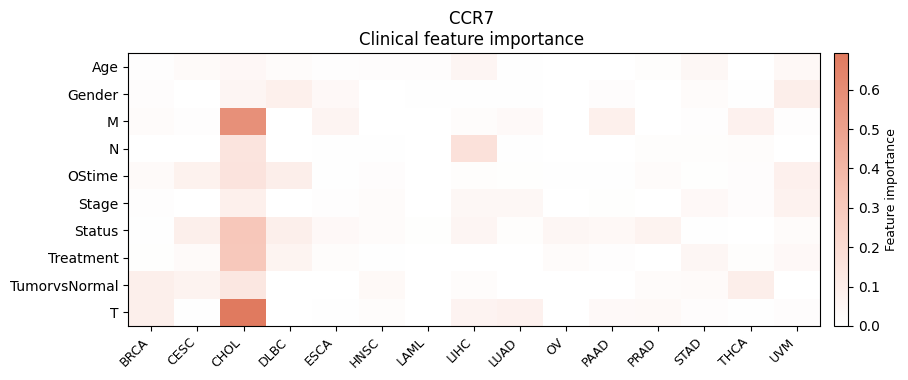

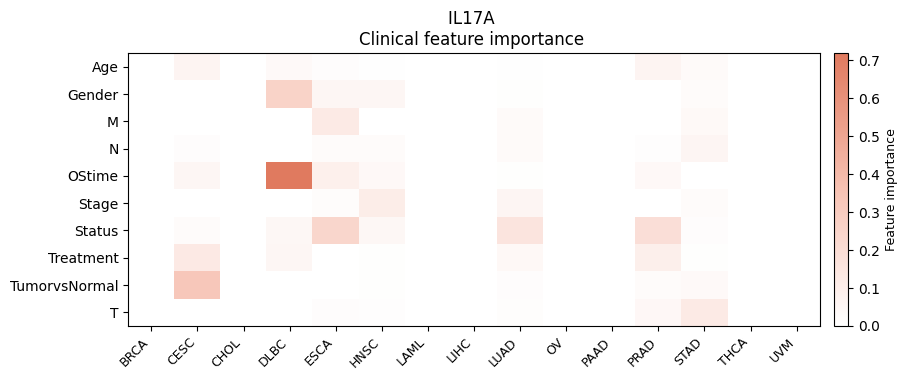

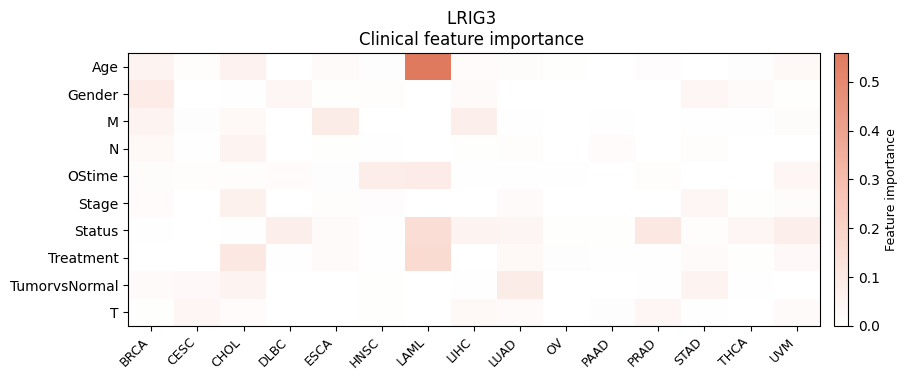

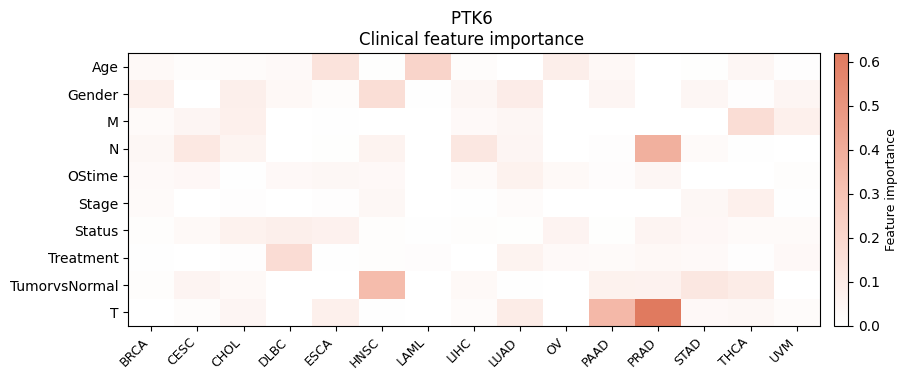

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os
cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#ffffff", "#F7C2B3"]
)

# ===== 基因的映射（protein_node_id -> gene_symbol）=====

# 读取 protein.txt
with open("./data/protein.txt", "r") as f:
    protein_list = [line.strip() for line in f]

# 索引列表
indices = [895, 1564, 2222, 7095, 8335, 12270]

gene_map = {idx: protein_list[idx] for idx in indices}
target_gene_ids = list(gene_map.keys())

# attr_cancer: [788,150]
# cancer_idx:  [788]  (对应 attr_cancer 每行的 protein_node_id)
# feature_names: len=150
# clinical_factors: len=10

attr_np = attr_cancer.detach().cpu().numpy()
cancer_idx_np = cancer_idx.detach().cpu().numpy()

# ===== 解析癌症类型顺序（15种）=====
cancer_types = []
for fn in feature_names:
    c = fn.split("TCGA-")[-1]
    if c not in cancer_types:
        cancer_types.append(c)

print("Cancer types:", cancer_types)
print("Num cancers:", len(cancer_types))

# ===== 建立 (factor, cancer) -> feature列索引 =====
feat_index = {}
for i, fname in enumerate(feature_names):
    fac = fname.split("_TCGA-")[0]
    can = fname.split("TCGA-")[-1]
    feat_index[(fac, can)] = i

# ===== 画图 =====
for gene_id in target_gene_ids:
    gene_name = gene_map.get(gene_id, str(gene_id))

    if gene_id not in cancer_idx_np:
        print(f"[Warning] {gene_name} (id={gene_id}) not in cancer_idx, skipped.")
        continue

    row_id = np.where(cancer_idx_np == gene_id)[0][0]

    # 10×15 热图矩阵：行=临床因子，列=癌种
    heatmap = np.zeros((len(clinical_factors), len(cancer_types)), dtype=float)
    for i, fac in enumerate(clinical_factors):
        for j, can in enumerate(cancer_types):
            col = feat_index[(fac, can)]
            heatmap[i, j] = abs(attr_np[row_id, col])  # 重要：取绝对值，避免正负抵消导致“看起来很小”

    fig, ax = plt.subplots(figsize=(9.2, 3.9))
    cmap_color = LinearSegmentedColormap.from_list(
    "custom",
    ["#ffffff", "#F7C2B3", "#E07A5F"]
    )
    im = ax.imshow(heatmap, aspect="auto", cmap=cmap_color)

    ax.set_xticks(np.arange(len(cancer_types)))
    ax.set_xticklabels(cancer_types, rotation=45, ha="right", fontsize=9)

    ax.set_yticks(np.arange(len(clinical_factors)))
    ax.set_yticklabels(clinical_factors, fontsize=10)

    ax.set_title(f"{gene_name} \nClinical feature importance ", fontsize=12)

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Feature importance", fontsize=9)

    plt.tight_layout()
    pdf_path = os.path.join(f'./figure', f"{gene_name}_gene_cli_impor.pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()


In [22]:
# 画注意力图
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = next(model_best.parameters()).device
hetero_data_device = hetero_data.to(device)
x_dict_device = {k: v.to(device) for k, v in x_dict.items()}

def enable_attn_cache(model, enabled=True):
    for layer in model.encoder.layers[-1:]:   # 只用最后一层
        for conv in layer.rel_convs.values():
            if hasattr(conv, "cache_attn"):
                conv.cache_attn = enabled
    return model.encoder.layers[-1]

# 打开缓存并 forward
last_layer = enable_attn_cache(model_best, True)
model_best.eval()
with torch.no_grad():
    _ = model_best(x_dict_device, hetero_data_device)

print("Relations with attention:", list(last_layer.rel_convs.keys()))


Relations with attention: ['lncrna__lncrnaTOlncrna__lncrna', 'lncrna__lncrnaTOmirna__mirna', 'lncrna__lncrnaTOprotein__protein', 'mirna__mirnaTOlncrna__lncrna', 'mirna__mirnaTOmirna__mirna', 'mirna__mirnaTOprotein__protein', 'protein__proteinTOlncrna__lncrna', 'protein__proteinTOmirna__mirna', 'protein__proteinTOprotein__protein']


In [23]:
def collect_all_relation_attn(layer):
    rows = []
    for key, conv in layer.rel_convs.items():
        src_t, rel, dst_t = key.split("__")
        ei = conv.last_edge_index.cpu().numpy()
        al = conv.last_alpha.cpu().numpy().reshape(-1)
        for i in range(ei.shape[1]):
            rows.append([
                src_t, int(ei[0,i]), rel,
                dst_t, int(ei[1,i]), float(al[i])
            ])
    return pd.DataFrame(
        rows,
        columns=["src_type","src","rel","dst_type","dst","alpha"]
    )

df_all = collect_all_relation_attn(last_layer)
print("Total edges with attention:", len(df_all))
df_all.head()


Total edges with attention: 1995296


,src_type,src,rel,dst_type,dst,alpha
0,lncrna,5,lncrnaTOlncrna,lncrna,1747,0.660532
1,lncrna,31,lncrnaTOlncrna,lncrna,1325,0.542093
2,lncrna,48,lncrnaTOlncrna,lncrna,1570,0.769822
3,lncrna,53,lncrnaTOlncrna,lncrna,1330,0.727018
4,lncrna,86,lncrnaTOlncrna,lncrna,1010,0.779058


In [24]:
import pandas as pd

def build_hetero_subgraph_hop2_balanced(
    df_all,
    target_protein,
    topk_per_type=3,     # 每种 dst_type 取多少条（比原先更均衡）
    max_per_node=8,      # 每个节点最多拿多少条（防止爆炸）
    undirected=True,
    required_types=("protein","mirna","lncrna")
):
    # 1) 无向展开（可选）
    if undirected:
        df_rev = df_all.rename(columns={
            "src_type":"dst_type","src":"dst",
            "dst_type":"src_type","dst":"src"
        })
        df2 = pd.concat([df_all, df_rev], ignore_index=True)
    else:
        df2 = df_all

    nodes = {t:set() for t in required_types}
    nodes["protein"].add(int(target_protein))

    frontier = {("protein", int(target_protein))}
    all_edges = []

    # hop=2
    for _ in range(2):
        new_frontier = set()

        for st, sid in frontier:
            # 取出该点出发的所有边
            cand_all = df2[(df2.src_type == st) & (df2.src == sid)].copy()
            if cand_all.empty:
                continue

            # 2) 按 dst_type 分组，各取 topk_per_type
            chosen_parts = []
            for dt in required_types:
                part = cand_all[cand_all.dst_type == dt].sort_values("alpha", ascending=False).head(topk_per_type)
                if not part.empty:
                    chosen_parts.append(part)

            if len(chosen_parts) == 0:
                continue

            cand = pd.concat(chosen_parts, ignore_index=True)

            # 3) 再做一次“每节点最多 max_per_node”截断（防止太多）
            cand = cand.sort_values("alpha", ascending=False).head(max_per_node)

            all_edges.append(cand)

            # 更新 frontier / nodes
            for _, r in cand.iterrows():
                dt, did = r["dst_type"], int(r["dst"])
                if dt in nodes:
                    if did not in nodes[dt]:
                        new_frontier.add((dt, did))
                    nodes[dt].add(did)

        frontier = new_frontier
        if len(frontier) == 0:
            break

    sub_edges = pd.concat(all_edges, ignore_index=True).drop_duplicates(
        subset=["src_type","src","rel","dst_type","dst"], keep="first"
    )

    # 只保留子图内部边
    sub_edges = sub_edges[
        sub_edges.apply(
            lambda r: int(r["src"]) in nodes[r["src_type"]] and int(r["dst"]) in nodes[r["dst_type"]],
            axis=1
        )
    ].reset_index(drop=True)

    return nodes, sub_edges

In [ ]:
import numpy as np
import pandas as pd

def _edge_group(r):
    """把边归到三类之一：PPI / P-M / P-L；否则 None"""
    a, b = r["src_type"], r["dst_type"]

    # 有空值或异常类型直接跳过
    if pd.isna(a) or pd.isna(b):
        return None

    pair = frozenset([a, b])   # 用 frozenset 表示“无序二元组”

    if pair == frozenset(["protein"]):              # protein-protein（含自环）
        return "PPI"
    if pair == frozenset(["protein", "mirna"]):
        return "P-M"
    if pair == frozenset(["protein", "lncrna"]):
        return "P-L"
    return None

def prune_edges_connected_type_constraints(
    sub_edges,
    target_protein,
    max_edges=25,
    must_groups=("PPI", "P-M", "P-L")
):
    """
    从 sub_edges 中挑 max_edges 条边：
    1) 必须包含 PPI / P-M / P-L 三类（如果候选里有的话）
    2) 尽量保持与 target_protein 连通（连通优先）
    3) 在满足约束下，按 alpha 尽量大
    """
    df = sub_edges.copy()
    df["group"] = df.apply(_edge_group, axis=1)

    # --- 先挑“必须边”：每个 group 取 alpha 最大的一条（尽量靠近中心更好，但这里先简单取最大）---
    chosen = []
    for g in must_groups:
        cand_g = df[df["group"] == g]
        if not cand_g.empty:
            chosen.append(cand_g.sort_values("alpha", ascending=False).iloc[0])

    chosen_df = pd.DataFrame(chosen).drop_duplicates(
        subset=["src_type","src","rel","dst_type","dst"], keep="first"
    )

    # --- 然后补齐剩余边：按 alpha 从高到低，且尽量保持连通 ---
    # 我们用一个简单的“连通集合”贪心：从中心开始，只加能连到已选节点集合的边
    selected_edges = chosen_df.copy()

    # 初始化“已连通节点集合”
    connected_nodes = {("protein", int(target_protein))}
    # 把 must edges 的端点也加进去（如果能连上）
    # 先做一轮扩展，允许它们把 connected 扩起来
    def add_edge_and_expand(row):
        nonlocal connected_nodes
        s = (row["src_type"], int(row["src"]))
        d = (row["dst_type"], int(row["dst"]))
        if s in connected_nodes or d in connected_nodes:
            connected_nodes.add(s); connected_nodes.add(d)
            return True
        return False

    # 多轮扩展，直到不再增长
    changed = True
    while changed:
        changed = False
        for _, r in selected_edges.iterrows():
            if add_edge_and_expand(r):
                changed = True

    # 候选池：去掉已选边
    key_cols = ["src_type","src","rel","dst_type","dst"]
    pool = df.merge(selected_edges[key_cols], on=key_cols, how="left", indicator=True)
    pool = pool[pool["_merge"] == "left_only"].drop(columns=["_merge"])

    pool = pool.sort_values("alpha", ascending=False)

    # 先加“能连到 connected_nodes 的边”
    for _, r in pool.iterrows():
        if len(selected_edges) >= max_edges:
            break
        s = (r["src_type"], int(r["src"]))
        d = (r["dst_type"], int(r["dst"]))
        if (s in connected_nodes) or (d in connected_nodes):
            selected_edges = pd.concat([selected_edges, r.to_frame().T], ignore_index=True)
            connected_nodes.add(s); connected_nodes.add(d)

    # 如果还不够 max_edges，就不再强制连通，直接按 alpha 补满（避免空缺）
    if len(selected_edges) < max_edges:
        remaining = pool.merge(selected_edges[key_cols], on=key_cols, how="left", indicator=True)
        remaining = remaining[remaining["_merge"]=="left_only"].drop(columns=["_merge"])
        need = max_edges - len(selected_edges)
        selected_edges = pd.concat([selected_edges, remaining.head(need)], ignore_index=True)

    # 清理列
    selected_edges = selected_edges.drop(columns=["group"], errors="ignore").reset_index(drop=True)
    return selected_edges

In [26]:
def plot_edge_list_heatmap(edges, title="", topn=25, figsize=(10, 6)):
    """
    edges: DataFrame，至少含 src_type/src/rel/dst_type/dst/alpha
    """
    e = edges.sort_values("alpha", ascending=False).head(topn).copy()
    e["edge"] = e.apply(lambda r: f'{r["src_type"]}:{int(r["src"])} --{r["rel"]}--> {r["dst_type"]}:{int(r["dst"])}', axis=1)

    # 变成 [topn, 1] 的矩阵，imshow 画热图
    A = e["alpha"].values.reshape(-1, 1)

    plt.figure(figsize=figsize)
    im = plt.imshow(A, aspect="auto", interpolation="nearest")
    plt.colorbar(im, fraction=0.03)
    plt.yticks(range(len(e)), e["edge"].tolist(), fontsize=8)
    plt.xticks([0], ["attention"])
    plt.title(title)
    plt.tight_layout()
    plt.show()



In [30]:
sub_pruned_dict = {}

targets = [17493, 11749,5525,15277,5510,5357,17162,5332]

for tid in targets:
    print("\n" + "="*80)
    print(f"Target protein: {tid}")

    # 1) hop=2 构建候选子图
    nodes_raw, sub_edges = build_hetero_subgraph_hop2_balanced(
        df_all,
        target_protein=tid,
        topk_per_type=3,
        max_per_node=8,
        undirected=True
    )

    print(f"Candidate edges (hop=2): {len(sub_edges)}")

    # 2) 连通约束下裁剪到 Top-25
    sub_pruned = prune_edges_connected_type_constraints(
        sub_edges,
        target_protein=tid,
        max_edges=25
    )

    print(f"Final edges (connected top-25): {len(sub_pruned)}")

    #  保存到字典（关键）
    sub_pruned_dict[tid] = sub_pruned.copy()

    # 输出查看

    display(
        sub_pruned[["src_type","src","rel","dst_type","dst","alpha"]]
        .sort_values("alpha", ascending=False)
    )



Target protein: 17493
Candidate edges (hop=2): 51
Final edges (connected top-25): 25


,src_type,src,rel,dst_type,dst,alpha
1,mirna,44,mirnaTOprotein,protein,9381,0.997708
3,protein,17493,mirnaTOprotein,mirna,407,0.996811
4,protein,17493,mirnaTOprotein,mirna,44,0.996778
5,protein,17493,mirnaTOprotein,mirna,185,0.996685
2,lncrna,361,lncrnaTOprotein,protein,14995,0.983842
6,protein,17493,lncrnaTOprotein,lncrna,361,0.921585
7,protein,17493,lncrnaTOprotein,lncrna,784,0.914938
8,mirna,407,mirnaTOlncrna,lncrna,227,0.804871
9,mirna,407,mirnaTOlncrna,lncrna,517,0.795936
10,mirna,185,mirnaTOlncrna,lncrna,517,0.793974



Target protein: 11749
Candidate edges (hop=2): 59
Final edges (connected top-25): 25


,src_type,src,rel,dst_type,dst,alpha
1,mirna,257,mirnaTOprotein,protein,16861,0.99767
3,protein,11749,mirnaTOprotein,mirna,257,0.993938
4,protein,11749,mirnaTOprotein,mirna,208,0.993711
5,protein,11749,mirnaTOprotein,mirna,756,0.993653
2,lncrna,1330,lncrnaTOprotein,protein,5638,0.988516
6,protein,11749,lncrnaTOprotein,lncrna,1221,0.974297
7,lncrna,1221,lncrnaTOprotein,protein,11749,0.974297
8,lncrna,1221,lncrnaTOprotein,protein,15099,0.974014
9,protein,11749,lncrnaTOprotein,lncrna,1330,0.970945
10,protein,11749,lncrnaTOprotein,lncrna,1609,0.965843



Target protein: 5525
Candidate edges (hop=2): 49
Final edges (connected top-25): 25


...

,src_type,src,rel,dst_type,dst,alpha
1,mirna,292,mirnaTOprotein,protein,11347,0.998035
23,mirna,292,mirnaTOprotein,protein,9381,0.99781
24,mirna,292,mirnaTOprotein,protein,5267,0.997732
3,protein,5357,mirnaTOprotein,mirna,1067,0.993843
4,protein,5357,mirnaTOprotein,mirna,292,0.993824
5,protein,5357,mirnaTOprotein,mirna,1410,0.993797
2,lncrna,221,lncrnaTOprotein,protein,5638,0.989967
6,protein,5357,lncrnaTOprotein,lncrna,1591,0.977812
7,protein,5357,lncrnaTOprotein,lncrna,1467,0.974461
8,protein,5357,lncrnaTOprotein,lncrna,221,0.973726



Target protein: 17162
Candidate edges (hop=2): 51
Final edges (connected top-25): 25


,src_type,src,rel,dst_type,dst,alpha
1,mirna,10,mirnaTOprotein,protein,5541,0.997659
20,mirna,208,mirnaTOprotein,protein,16861,0.997638
21,mirna,10,mirnaTOprotein,protein,2674,0.997628
22,mirna,206,mirnaTOprotein,protein,11206,0.997615
23,mirna,10,mirnaTOprotein,protein,7755,0.997614
24,mirna,208,mirnaTOprotein,protein,2674,0.997613
3,protein,17162,mirnaTOprotein,mirna,10,0.996121
4,protein,17162,mirnaTOprotein,mirna,206,0.996069
5,protein,17162,mirnaTOprotein,mirna,208,0.996031
2,lncrna,1070,lncrnaTOprotein,protein,3406,0.977531



Target protein: 5332
Candidate edges (hop=2): 53
Final edges (connected top-25): 25


,src_type,src,rel,dst_type,dst,alpha
1,mirna,409,mirnaTOprotein,protein,11347,0.997989
3,protein,5332,mirnaTOprotein,mirna,1557,0.997338
4,mirna,1557,mirnaTOprotein,protein,5332,0.997338
5,mirna,1557,mirnaTOprotein,protein,8048,0.997307
6,protein,5332,mirnaTOprotein,mirna,1197,0.997158
7,protein,5332,mirnaTOprotein,mirna,409,0.997099
2,lncrna,1330,lncrnaTOprotein,protein,5638,0.988516
8,protein,5332,lncrnaTOprotein,lncrna,1330,0.939562
9,protein,5332,lncrnaTOprotein,lncrna,1255,0.849411
10,protein,5332,proteinTOlncrna,lncrna,1330,0.814013


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ======================================================
# 0) 读取名字映射（请确认路径）
# ======================================================
# 读取 protein.txt
with open("./data/protein.txt", "r") as f:
    protein_names = [line.strip() for line in f]
with open("./data/lncrna.txt", "r") as f:
    lncrna_names = [line.strip() for line in f]
with open("./data/mirna.txt", "r") as f:
    mirna_names = [line.strip() for line in f]
# 索引列表
indices = [895, 1564, 2222, 7095, 8335, 12270]


def id_to_name(ntype, nid):
    nid = int(nid)
    if ntype == "protein":
        if isinstance(protein_names, list) and 0 <= nid < len(protein_names):
            return protein_names[nid]
        if isinstance(protein_names, dict):
            return protein_names.get(nid, protein_names.get(str(nid), f"protein:{nid}"))
        return f"protein:{nid}"
    elif ntype == "mirna":
        if isinstance(mirna_names, list) and 0 <= nid < len(mirna_names):
            return mirna_names[nid]
        if isinstance(mirna_names, dict):
            return mirna_names.get(nid, mirna_names.get(str(nid), f"mirna:{nid}"))
        return f"mirna:{nid}"
    elif ntype == "lncrna":
        if isinstance(lncrna_names, list) and 0 <= nid < len(lncrna_names):
            return lncrna_names[nid]
        if isinstance(lncrna_names, dict):
            return lncrna_names.get(nid, lncrna_names.get(str(nid), f"lncrna:{nid}"))
        return f"lncrna:{nid}"
    return str(nid)


# ======================================================
# 1) 画：子网络 + 全节点注意力矩阵（不区分类型）
# ======================================================
def plot_subnetwork_with_attention_matrix(sub_pruned, center_id, seed=7, figsize=(14, 6)):
    """
    sub_pruned: DataFrame with columns:
        ["src_type","src","rel","dst_type","dst","alpha"]
    center_id:  int, protein id (中心蛋白)
    protein_y:  外部需要存在（tensor 或 np array），protein_y[nid]==1 表示癌症基因
    """

    # ---------- 1) 构建节点与边 ----------
    nodes = set()
    edges = []  # (node_u, node_v, alpha)

    for _, r in sub_pruned.iterrows():
        s = (r["src_type"], int(r["src"]))
        d = (r["dst_type"], int(r["dst"]))
        nodes.add(s)
        nodes.add(d)
        edges.append((s, d, float(r["alpha"])))

    nodes = list(nodes)
    idx = {n: i for i, n in enumerate(nodes)}
    n = len(nodes)

    # ---------- 2) 简单 spring layout（不用 networkx） ----------
    rng = np.random.default_rng(seed)
    pos = rng.normal(0, 1, size=(n, 2))
    k = 1.0 / np.sqrt(max(n, 1))
    lr = 0.02
    iters = 450

    # 预备边索引
    E = [(idx[s], idx[d]) for (s, d, a) in edges]

    for _ in range(iters):
        disp = np.zeros_like(pos)

        # repulsion
        for i in range(n):
            for j in range(i + 1, n):
                delta = pos[i] - pos[j]
                dist = np.linalg.norm(delta) + 1e-6
                force = (k * k) / dist
                dvec = (delta / dist) * force
                disp[i] += dvec
                disp[j] -= dvec

        # attraction
        for (i, j) in E:
            delta = pos[i] - pos[j]
            dist = np.linalg.norm(delta) + 1e-6
            force = (dist * dist) / k
            dvec = (delta / dist) * force
            disp[i] -= dvec
            disp[j] += dvec

        pos += lr * disp
        pos /= (np.max(np.abs(pos)) + 1e-6)

    # ======================================================
    # 左：网络图
    # ======================================================
    fig = plt.figure(figsize=figsize)
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.axis("off")

    # 边统一灰色
    for (s, d, a) in edges:
        i, j = idx[s], idx[d]
        ax1.plot([pos[i, 0], pos[j, 0]],
                 [pos[i, 1], pos[j, 1]],
                 color="gray",
                 linewidth=2.0,
                 alpha=0.6,
                 zorder=1)

    # 节点配色与形状
    color_mirna  = "#D8F0F6"
    color_lncrna = "#F4E0FA"
    color_prot_other = "#1f77b4"

    for i, (ntype, nid) in enumerate(nodes):
        x, y = pos[i]
        label = id_to_name(ntype, nid)

        if ntype == "protein":
            if nid == int(center_id):
                color = "orange"
                size = 380
            else:
                # protein_y 外部提供：1=癌症基因
                try:
                    is_cancer = int(protein_y[nid]) == 1
                except Exception:
                    is_cancer = False
                color = "red" if is_cancer else color_prot_other
                size = 280

            ax1.scatter(x, y, s=size, marker="o",
                        color=color, edgecolors="black",
                        linewidths=1.0, zorder=3)

        elif ntype == "mirna":
            ax1.scatter(x, y, s=260, marker="^",
                        color=color_mirna, edgecolors="black",
                        linewidths=1.0, zorder=3)

        elif ntype == "lncrna":
            ax1.scatter(x, y, s=280, marker="h",   # 正六边形
                        color=color_lncrna, edgecolors="black",
                        linewidths=1.0, zorder=3)

        # 名字标签
        ax1.text(x, y + 0.05, label, fontsize=10,
                 ha="center", va="bottom", zorder=4)

    ax1.set_title(f"Subnetwork of {id_to_name('protein', center_id)}",
                  fontsize=13)

    # ======================================================
    # 右：全节点注意力矩阵（不区分类型）
    # ======================================================
    ax2 = fig.add_subplot(1, 2, 2)

    # 构建 NxN matrix（无边=0，取无向最大/或对称写入）
    mat = np.zeros((n, n), dtype=float)
    for (s, d, a) in edges:
        i, j = idx[s], idx[d]
        # 如果同一对出现多次，保留最大 alpha
        mat[i, j] = max(mat[i, j], a)
        mat[j, i] = max(mat[j, i], a)

    # 按节点总注意力排序（让结构更清晰）
    order = np.argsort(mat.sum(axis=1))[::-1]
    mat = mat[order][:, order]
    node_labels = [id_to_name(nodes[i][0], nodes[i][1]) for i in order]
    cmap_color2 = LinearSegmentedColormap.from_list(
        "custom",
        ["#ffffff", "#F7C2B3", "#E07A5F"]
        )

    im = ax2.imshow(mat, cmap=cmap_color2, aspect="auto")

    ax2.set_xticks(np.arange(n))
    ax2.set_xticklabels(node_labels, rotation=45, ha="right", fontsize=9)

    ax2.set_yticks(np.arange(n))
    ax2.set_yticklabels(node_labels, fontsize=9)

    ax2.set_title(f"Attention weights of {id_to_name('protein', center_id)}",
                  fontsize=13)

    cbar = plt.colorbar(im, ax=ax2, fraction=0.03, pad=0.02)
    cbar.set_label("Attention weights")

    plt.tight_layout()

    # ===== 保存=====
    import os
    save_dir = "./figure"
    os.makedirs(save_dir, exist_ok=True)

    center_name = id_to_name('protein', center_id)
    save_path = os.path.join(save_dir, f"subnetwork_{center_name}.pdf")

    plt.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=300,
        transparent=True
    )

    print(f"Figure saved to: {save_path}")

    plt.show()





Figure saved to: ./figure/subnetwork_YAP1.pdf


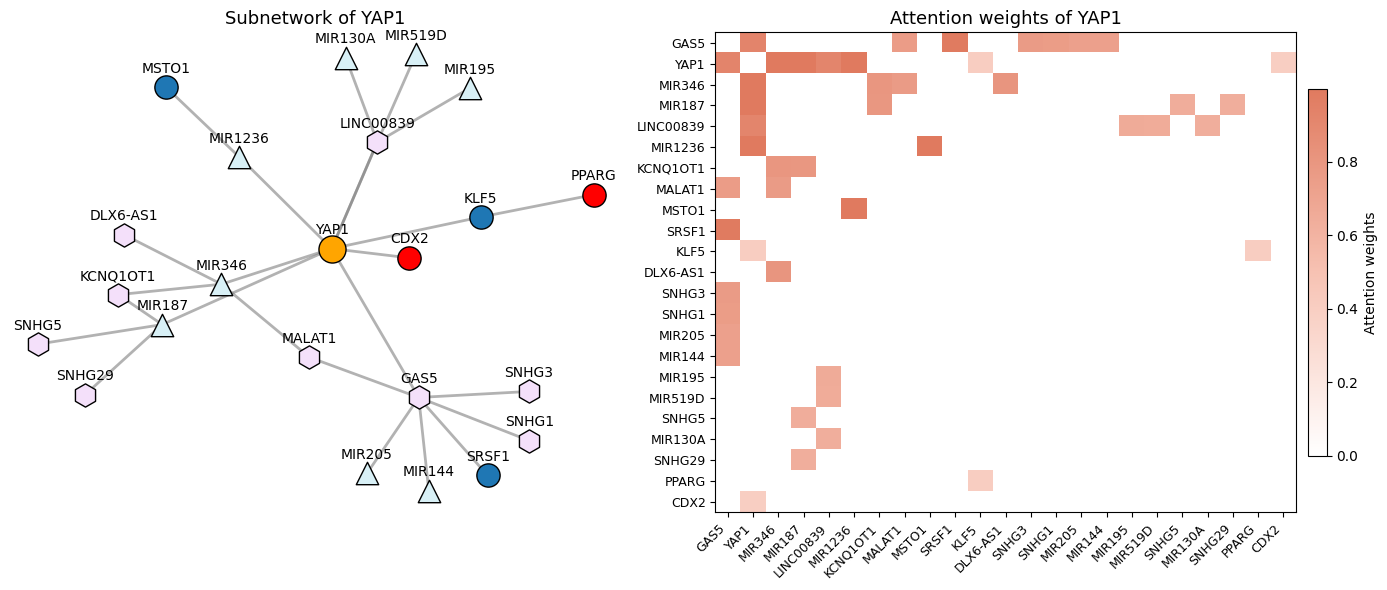

Figure saved to: ./figure/subnetwork_POU2F2.pdf


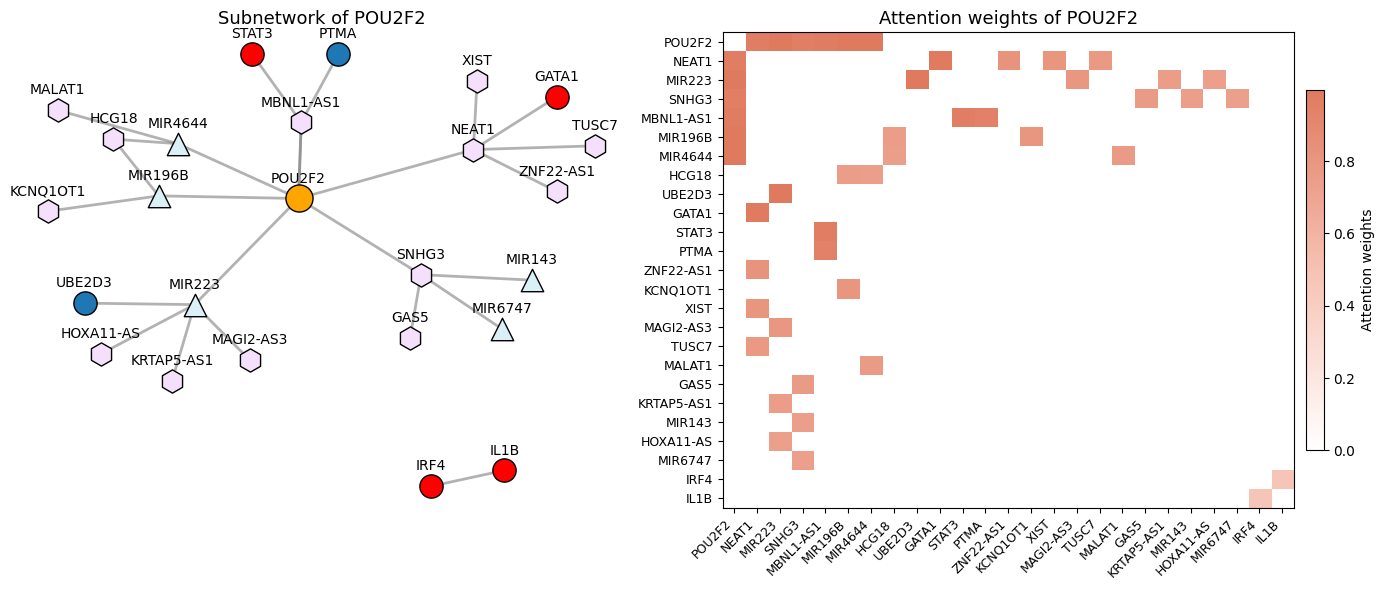

Figure saved to: ./figure/subnetwork_G3BP1.pdf


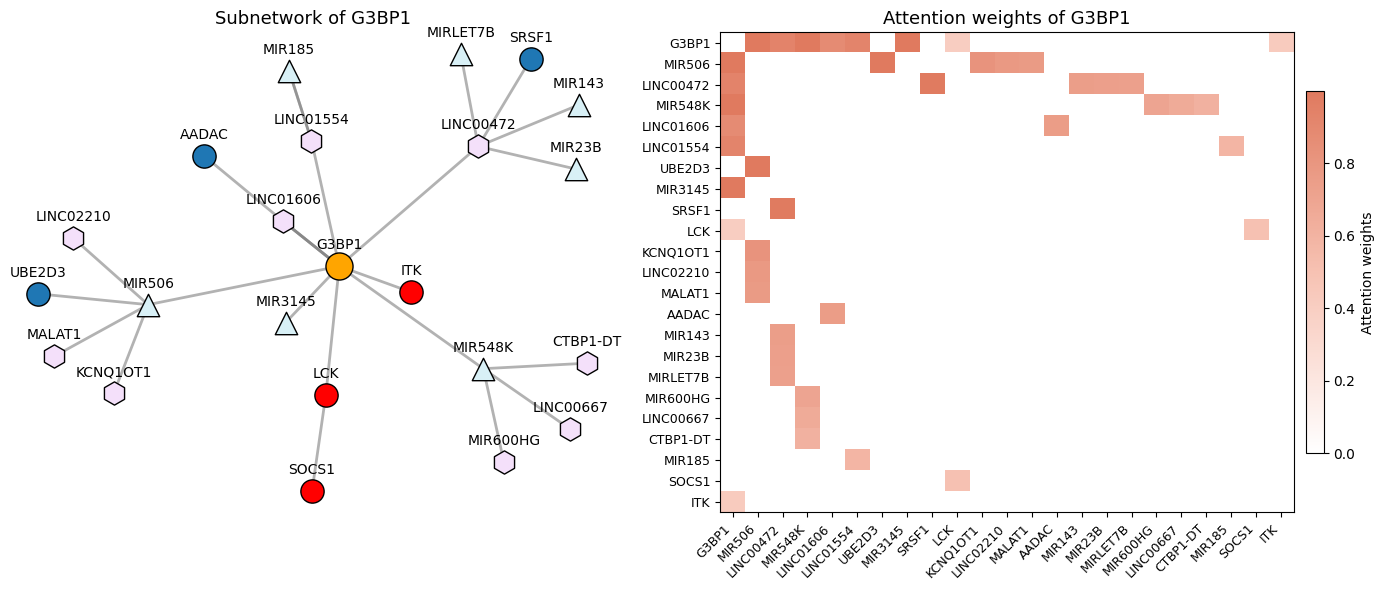

Figure saved to: ./figure/subnetwork_SVIL.pdf


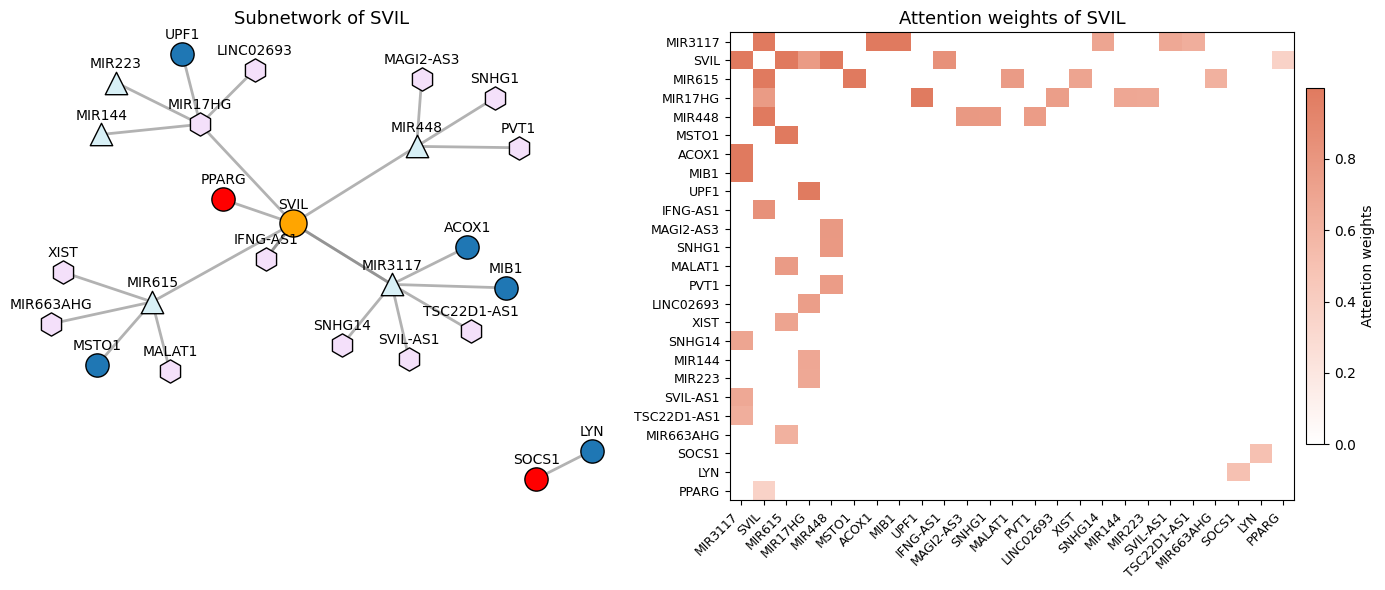

Figure saved to: ./figure/subnetwork_FYN.pdf


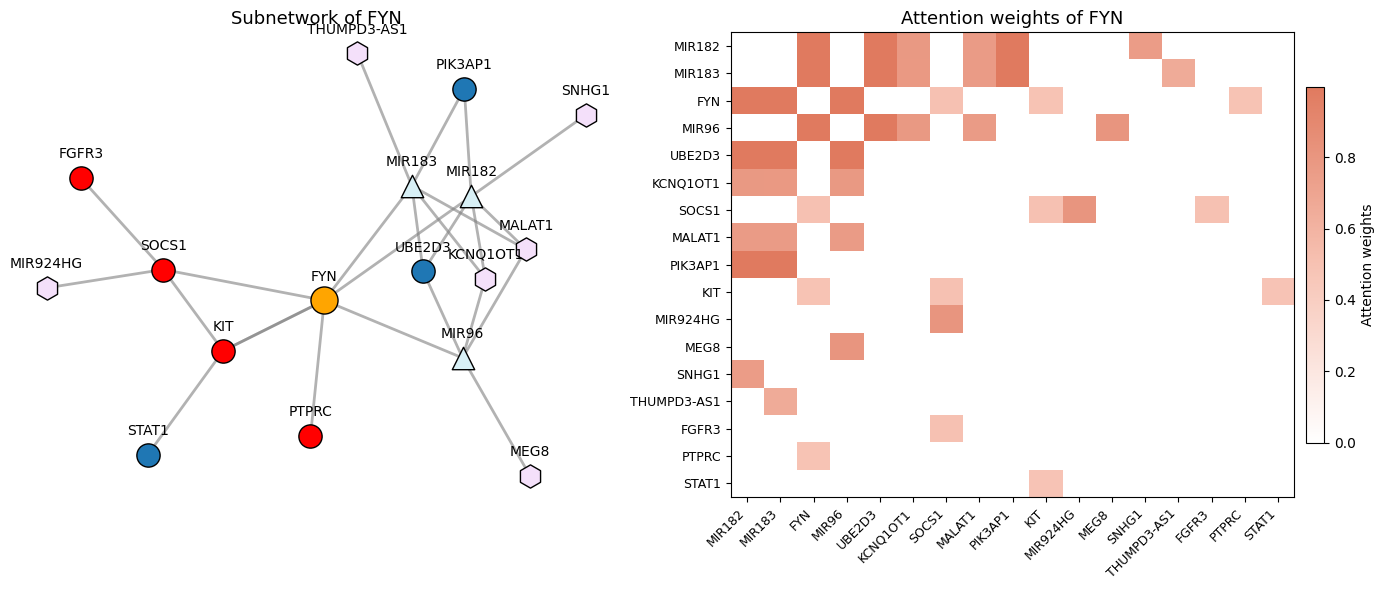

Figure saved to: ./figure/subnetwork_FOS.pdf


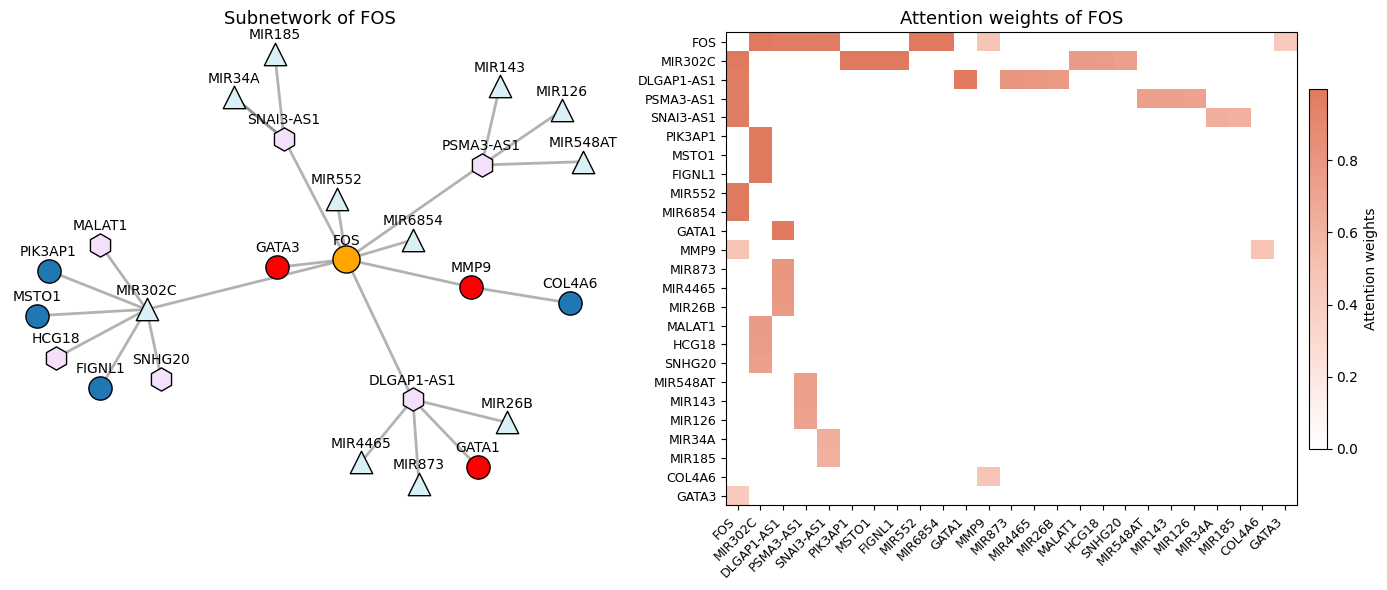

Figure saved to: ./figure/subnetwork_VCL.pdf


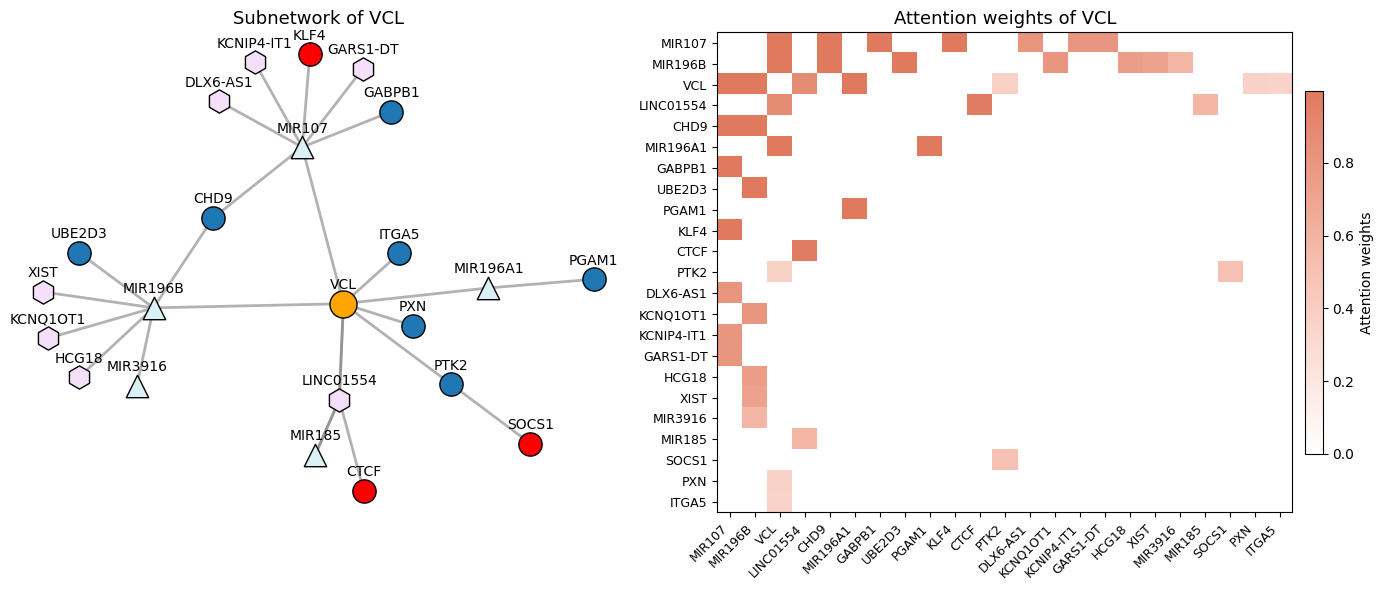

Figure saved to: ./figure/subnetwork_FN1.pdf


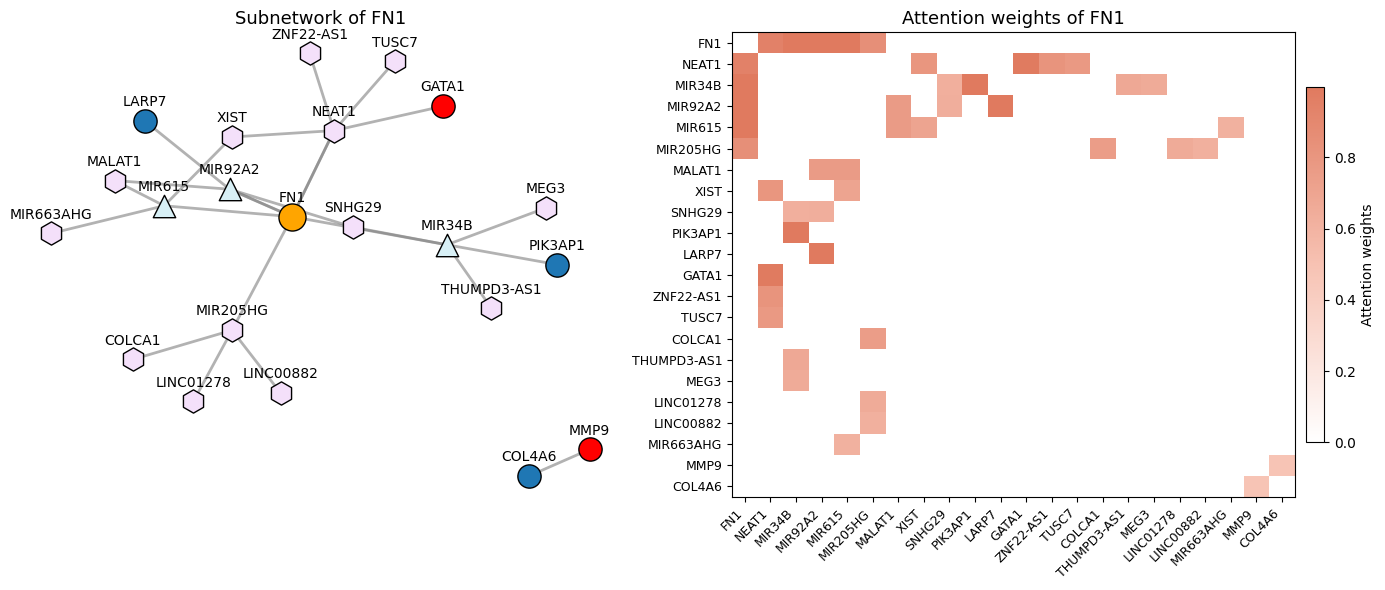

In [34]:
for tid in [17493, 11749,5525,15277,5510,5357,17162,5332]:
    plot_subnetwork_with_attention_matrix(sub_pruned_dict[tid], tid)